In [1]:
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from pathlib import Path
sys.path.insert(0, ".")
from pathconfig import RESULTS_DIR

import glob
import glob as _glob


import matplotlib as _mpl
_mpl.rcdefaults()
plt.rcParams.update({
    'axes.grid':       False,
    'axes.grid.which': 'both',
    'grid.linewidth':  0,
    'figure.dpi':      150,
    'font.size':       13,
    'axes.titlesize':  14,
    'axes.labelsize':  13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize':15,
})

## Results Reproduction Notebook 

This notebook reproduces the main results of the Masterthesis "Learning to Dispatch: Decision-Focused Learning for Wind Powered Energy Hubs".

In [2]:

MODEL_NAME  = "medium_autoreg_lstm_reg_overlap"   
WF_SCENARIO = "3gw"                               # "3gw" or "3800mw"
SCENARIO    = "baseline"                          # "baseline", "low_h2_price", "high_h2_price" 

if WF_SCENARIO == "3800mw" and SCENARIO and not SCENARIO.endswith("_3800mw"):
    SCENARIO = SCENARIO + "_3800mw"
P_RATED     = {"3gw": 3000, "3800mw": 3800}[WF_SCENARIO]

_scen_suffix = f"_{SCENARIO}" if SCENARIO else "" 


ORACLE_RESULTS_DIR = RESULTS_DIR                                       
ML_RESULTS_DIR     = RESULTS_DIR.parent / "results" 


SAMPLE_START = 384
SAMPLE_END   = SAMPLE_START + 672


FIG_DIR = RESULTS_DIR.parent / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
_fig_counter = [0]

import re as _re, inspect as _inspect

def _slugify(text):
    """Convert a label to a clean filename slug."""
    text = text.replace("\n", " ").lower()
    text = _re.sub(r"[/:\\|]", "-", text)   # keep readable separators
    text = _re.sub(r"[^\w\s-]", " ", text)  
    text = _re.sub(r"[\s_]+", "_", text).strip("_-")
    text = _re.sub(r"-_|_-", "-", text)       
    return text[:55]

def _scen_tag():
    """Short scenario tag for filenames: e.g. 3gw_baseline, 3800mw_low_h2."""
    wf   = WF_SCENARIO                               # "3gw" / "3800mw"
    scen = (SCENARIO or "no_scen").replace("_3800mw", "")  
    return f"{wf}_{scen}"

if not hasattr(plt, "_unpatched_show"):
    plt._unpatched_show = plt.show
_original_show = plt._unpatched_show

def _auto_save_show(*args, **kwargs):
    _fig_counter[0] += 1
    fig = plt.gcf()

  
    frame      = _inspect.currentframe().f_back
    locs       = frame.f_locals
    label_str  = (locs.get("label")          
               or locs.get("display_label")  
               or "")
    if not label_str:
       
        label_str = (fig._suptitle.get_text() if fig._suptitle else "")
        if not label_str:
            ax0 = fig.get_axes()
            label_str = ax0[0].get_title() if ax0 else ""
    if not label_str:
        label_str = f"fig_{_fig_counter[0]:02d}"

    slug  = _slugify(label_str)
    fname = f"{slug}-{_scen_tag()}.pdf"
    path  = FIG_DIR / fname
    fig.savefig(path, bbox_inches="tight", format="pdf")
    print(f"  -> Saved {fname}")
    _original_show(*args, **kwargs)
    plt.close(fig)

plt.show = _auto_save_show
print(f"Figures will be saved as PDF to: {FIG_DIR}")

Figures will be saved as PDF to: /Users/paulagattner/Desktop/Schreibtisch - MacBook Air von Paula/Uni/Master_CBS/4. Semester/GithubRepo/figures


In [3]:

pto_dir    = ML_RESULTS_DIR     / f"pto_{WF_SCENARIO}_test_{MODEL_NAME}{_scen_suffix}"
oracle_dir = ORACLE_RESULTS_DIR / f"oracle_{WF_SCENARIO}_test{_scen_suffix}"

#print(f"pto_dir   : {pto_dir}  exists={pto_dir.exists()}")
#print(f"oracle_dir: {oracle_dir}  exists={oracle_dir.exists()}")

pto    = pd.read_parquet(pto_dir    / "dispatch_pto.parquet")
oracle = pd.read_parquet(oracle_dir / "dispatch_oracle.parquet")

with open(pto_dir    / "summary.json") as f: pto_summary    = json.load(f)
with open(oracle_dir / "summary.json") as f: oracle_summary = json.load(f)

print(f"PTO dispatch:    {len(pto)} timesteps  ({pto.index[0]} -> {pto.index[-1]})")
print(f"Oracle dispatch: {len(oracle)} timesteps")
print(f"\nPTO planned profit  : EUR{pto_summary['objective_value']:,.2f}")
print(f"PTO realised profit : EUR{pto_summary.get('realized_profit', 'n/a'):}")
print(f"Oracle objective    : EUR{oracle_summary['objective_value']:,.2f}")


pred   = pto["P_wind_pred"]
actual = pto["P_wind_actual"]
prices = pto["spot_price"]


PTO dispatch:    41760 timesteps  (2024-10-22 16:00:00 -> 2025-12-31 15:45:00)
Oracle dispatch: 41789 timesteps

PTO planned profit  : EUR1,167,090,699.25
PTO realised profit : EUR524044976.7633329
Oracle objective    : EUR971,386,382.39


In [4]:

DFL_AVAILABLE = False
dfl = dfl_summary = None
dfl_pred = dfl_actual = None

dfl_dir = ML_RESULTS_DIR / f"dfl_{WF_SCENARIO}_{MODEL_NAME}{_scen_suffix}"
try:
    dfl        = pd.read_parquet(dfl_dir / "dispatch_dfl.parquet")
    with open(dfl_dir / "summary.json") as f: dfl_summary = json.load(f)
    DFL_AVAILABLE = True
    dfl_pred   = dfl["P_wind_pred"]
    dfl_actual = dfl["P_wind_actual"]
    print(f"DFL dispatch:    {len(dfl)} timesteps")
    print(f"DFL planned profit  : EUR{dfl_summary['objective_value']:,.2f}")
    print(f"DFL realised profit : EUR{dfl_summary.get('realized_profit', 'n/a'):}")
except FileNotFoundError:
    print(f"No DFL results found at {dfl_dir}")
    print("       DFL-related cells will be skipped automatically.")


DFL dispatch:    41760 timesteps
DFL planned profit  : EUR2,236,741,331.66
DFL realised profit : EUR948328226.7727262


## Forecast Evaluation

In [5]:
#Print all models and their best val MSEs for all scenarios and check which one is the best model

BASE = RESULTS_DIR.parent  


json_files = sorted(glob.glob(str(BASE / "**/checkpoints_*/**/*results*.json"), recursive=True) +
                    glob.glob(str(BASE / "checkpoints_*/*results*.json")))

rows = []
for fpath in json_files:
    p = Path(fpath)
    wf_scenario = p.parent.name.replace("checkpoints_", "")  

    with open(p) as fh:
        d = json.load(fh)

    cfg     = d.get("config", {})
    history = d.get("history", {})
    if not history:
        continue

    model_name   = cfg.get("name", p.stem.split("_results")[0])
    model_kwargs = cfg.get("model_kwargs", {})
    opt_args     = cfg.get("optimizer_args", {})

    val_mse  = history.get("val_mse",  [])
    val_rmse = history.get("val_rmse", [])
    val_mae  = history.get("val_mae",  [])

    if not val_mse:
        continue

    best_epoch = int(min(range(len(val_mse)), key=lambda i: val_mse[i]))

    rows.append({
        "WF scenario":   wf_scenario,
        "Model":         model_name,
        "Architecture":  "Autoreg-LSTM" if "autoreg" in model_name else "LSTM",
        "Hidden size":   model_kwargs.get("hidden_size", "—"),
        "Layers":        model_kwargs.get("num_layers",  "—"),
        "LR":            opt_args.get("lr", "—"),
        "Epochs run":    len(val_mse),
        "Best epoch":    best_epoch + 1,
        "Best val MSE":  round(val_mse[best_epoch],  4),
        "Best val RMSE": round(val_rmse[best_epoch], 4) if val_rmse else "—",
        "Best val MAE":  round(val_mae[best_epoch],  4) if val_mae  else "—",
        "_file":         p.name,   # hidden — used to flag duplicates
    })

df_models = pd.DataFrame(rows)

df_models = (df_models
             .sort_values("Best val MSE")
             .drop_duplicates(subset=["WF scenario", "Model"], keep="first")
             .drop(columns="_file")
             .sort_values(["WF scenario", "Best val MSE"])
             .reset_index(drop=True))


for wf, grp in df_models.groupby("WF scenario"):
    print(f"\n{'─'*90}")
    print(f"  WF Scenario: {wf.upper()}")
    print(f"{'─'*90}")
    display_cols = ["Model", "Architecture", "Hidden size", "Layers", "LR",
                    "Epochs run", "Best epoch", "Best val MSE", "Best val RMSE", "Best val MAE"]
    print(grp[display_cols].to_string(index=False))


print(f"\n★  Selected model for evaluation: {MODEL_NAME}")
sel = df_models[df_models["Model"] == MODEL_NAME]
if not sel.empty:
    row = sel.iloc[0]
    print(f"   Best val MSE  = {row['Best val MSE']}  |  "
          f"Best val RMSE = {row['Best val RMSE']}  |  "
          f"Best val MAE = {row['Best val MAE']}")


──────────────────────────────────────────────────────────────────────────────────────────
  WF Scenario: 3800MW
──────────────────────────────────────────────────────────────────────────────────────────
                          Model Architecture  Hidden size  Layers     LR  Epochs run  Best epoch  Best val MSE  Best val RMSE  Best val MAE
medium_autoreg_lstm_reg_overlap Autoreg-LSTM          512       3 0.0005          64          44        0.6338         0.7961        0.6267

──────────────────────────────────────────────────────────────────────────────────────────
  WF Scenario: 3GW
──────────────────────────────────────────────────────────────────────────────────────────
                                           Model Architecture  Hidden size  Layers     LR  Epochs run  Best epoch  Best val MSE  Best val RMSE  Best val MAE
                 medium_autoreg_lstm_reg_overlap Autoreg-LSTM          512       3 0.0005          60          40        0.6109         0.7816        0.6230

  -> Saved learning_curve_medium_autoreg_lstm_reg_overlap_3800mw-3gw_baseline.pdf


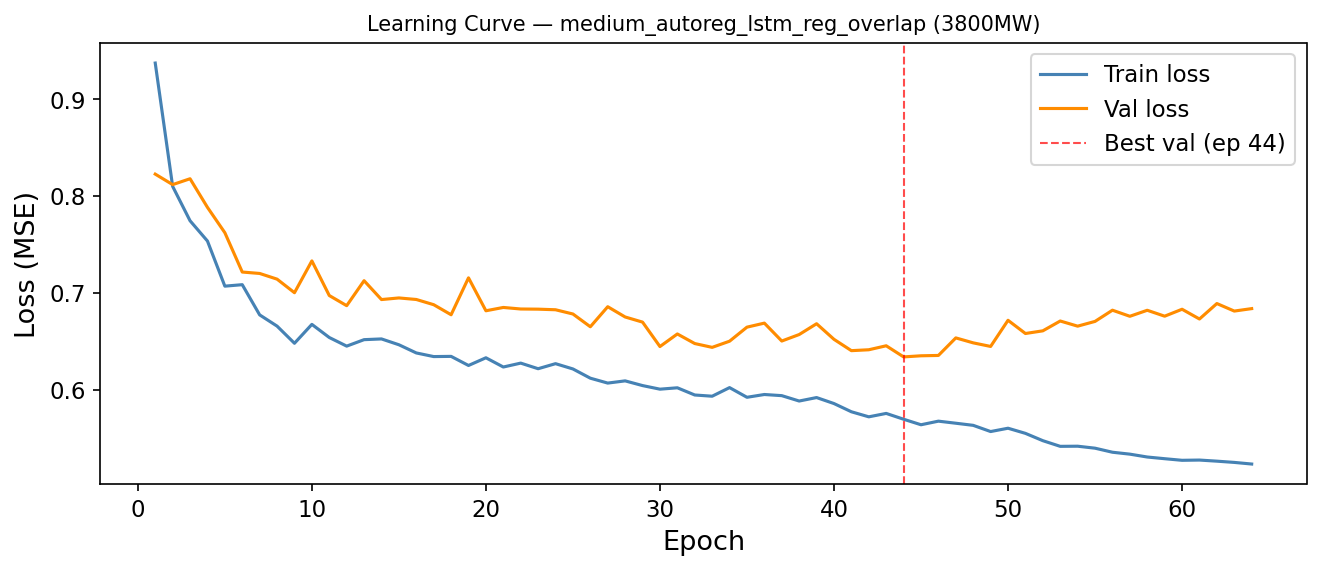

  -> Saved learning_curve_medium_autoreg_lstm_reg_overlap_3gw-3gw_baseline.pdf


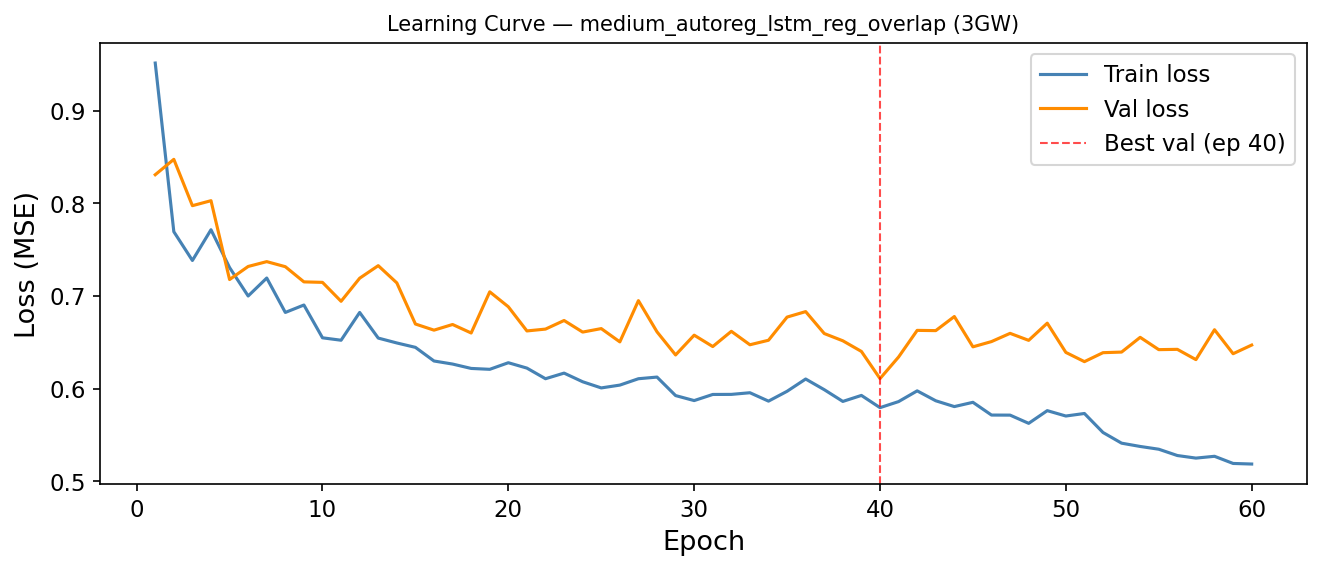

In [6]:
# Plot learning curve for the selected model only
for wf, grp in df_models.groupby("WF scenario"):
    grp = grp[grp["Model"] == MODEL_NAME]
    if grp.empty:
        continue

    model_name = MODEL_NAME
    fig, ax = plt.subplots(figsize=(9, 4))

    pattern = str(BASE / f"**/checkpoints_{wf}/**/{model_name}_results*.json")
    matches = sorted(glob.glob(pattern, recursive=True))
    if not matches:
        print(f"No results file found for {model_name} in {wf}")
        plt.close(fig)
        continue

    best_file = min(matches, key=lambda f: min(json.load(open(f))["history"]["val_mse"]))
    d = json.load(open(best_file))
    h = d["history"]
    epochs = range(1, len(h["train_loss"]) + 1)
    ax.plot(epochs, h["train_loss"], color="steelblue",  lw=1.5, label="Train loss")
    ax.plot(epochs, h["val_loss"],   color="darkorange", lw=1.5, label="Val loss")
    best_ep = int(min(range(len(h["val_mse"])), key=lambda i: h["val_mse"][i]))
    ax.axvline(best_ep + 1, color="red", lw=1, linestyle="--", alpha=0.7, label=f"Best val (ep {best_ep+1})")
    ax.set_title(f"Learning Curve — {model_name} ({wf.upper()})", fontsize=10)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (MSE)")
    ax.legend()

    plt.tight_layout(); plt.show()

=== Scaled metrics (training history units) ===


/opt/anaconda3/envs/bornholm_wake/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,Best epoch,Train MSE,Train RMSE,Train MAE,Val MSE,Val RMSE,Val MAE
WF scenario,,,,,,,
3gw,40,0.5795,0.7613,0.5985,0.6109,0.7816,0.6230
3800mw,33,0.5623,0.7499,0.5852,0.6387,0.7992,0.6239



=== Physical units (MW) ===
  MSE_MW2 = MSE_scaled x std_MW^2  |  RMSE_MW = RMSE_scaled x std_MW  |  MAE_MW = MAE_scaled x std_MW


,Best epoch,std_mw,Train MSE MW2,Train RMSE MW,Train MAE MW,Val MSE MW2,Val RMSE MW,Val MAE MW
WF scenario,,,,,,,,
3gw,40,901.6,471045.0,686.3,539.6,496511.0,704.6,561.6
3800mw,33,1140.5,731362.0,855.2,667.5,830747.0,911.5,711.5


  -> Saved medium_autoreg_lstm_reg_overlap_best-epoch_metrics_in_m-3gw_baseline.pdf


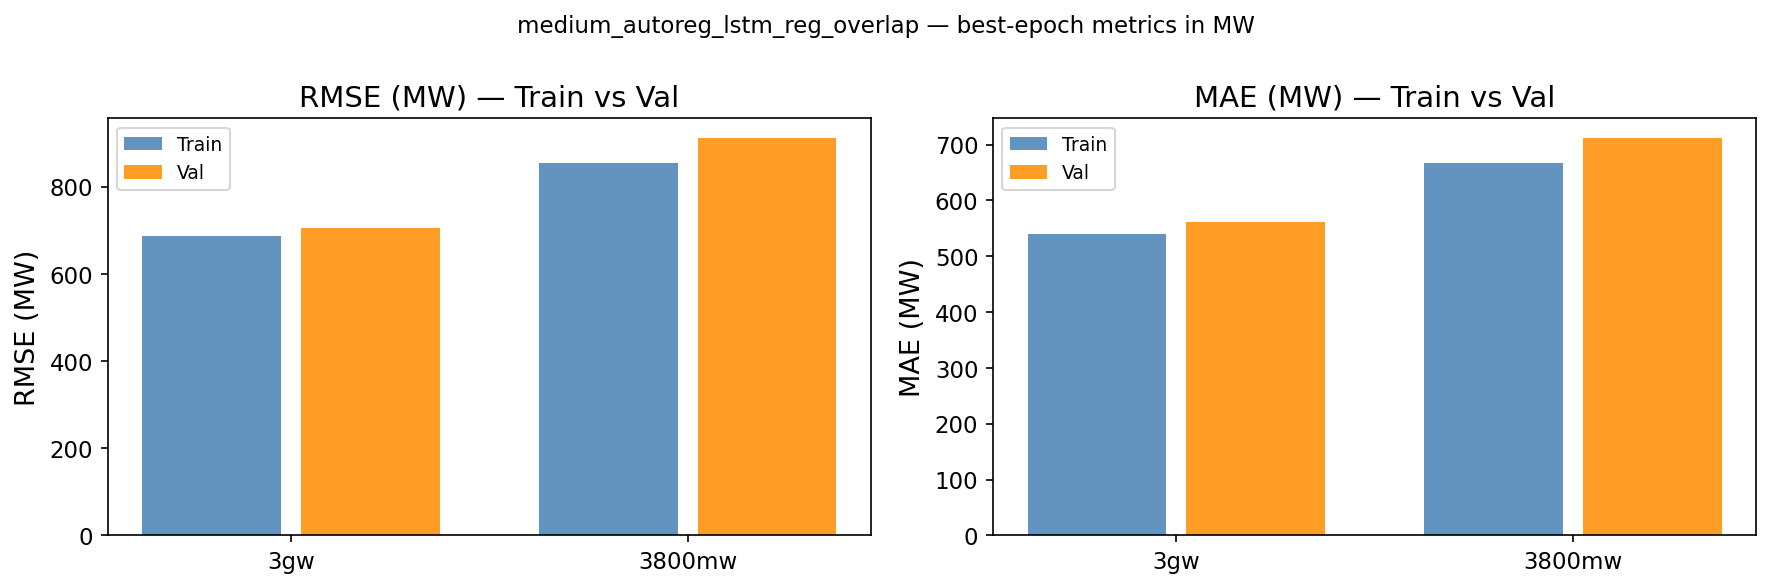

In [7]:
# Show values in scaled units and MW for the selected model

CKPT_BASE = RESULTS_DIR.parent
MODEL_KEY  = 'medium_autoreg_lstm_reg_overlap'
WF_LIST    = ['3gw', '3800mw']

metric_rows = []
for wf in WF_LIST:
   
    import joblib as _jl
    sc_target = _jl.load(CKPT_BASE / f'data_splits_{wf}' / 'target_scaler.joblib')
    std_mw = sc_target.scale_[0]

    files = sorted((CKPT_BASE / f'checkpoints_{wf}').glob(f'{MODEL_KEY}_results-*.json'))
    if not files:
        print(f'No JSON found for {MODEL_KEY} in checkpoints_{wf}')
        continue
    with open(files[-1]) as fh:
        hist = json.load(fh)['history']

    best_ep = int(np.argmin(hist['val_mse']))

    row = {
        'WF scenario':    wf,
        'Best epoch':     best_ep + 1,
        'Train MSE':      round(hist['train_mse'][best_ep],  4),
        'Train RMSE':     round(hist['train_rmse'][best_ep], 4),
        'Train MAE':      round(hist['train_mae'][best_ep],  4),
        'Val MSE':        round(hist['val_mse'][best_ep],    4),
        'Val RMSE':       round(hist['val_rmse'][best_ep],   4),
        'Val MAE':        round(hist['val_mae'][best_ep],    4),
        # Physical units print below:
        'Train RMSE MW':  round(hist['train_rmse'][best_ep] * std_mw, 1),
        'Train MAE MW':   round(hist['train_mae'][best_ep]  * std_mw, 1),
        'Val RMSE MW':    round(hist['val_rmse'][best_ep]   * std_mw, 1),
        'Val MAE MW':     round(hist['val_mae'][best_ep]    * std_mw, 1),
        'Train MSE MW2':  round(hist['train_mse'][best_ep] * std_mw**2, 0),
        'Val MSE MW2':    round(hist['val_mse'][best_ep]   * std_mw**2, 0),
        'std_mw':         round(std_mw, 1),
    }
    metric_rows.append(row)

if metric_rows:
    df_m = pd.DataFrame(metric_rows).set_index('WF scenario')

    print('=== Scaled metrics (training history units) ===')
    display(df_m[['Best epoch','Train MSE','Train RMSE','Train MAE','Val MSE','Val RMSE','Val MAE']])

    print('\n=== Physical units (MW) ===')
    print('  MSE_MW2 = MSE_scaled x std_MW^2  |  RMSE_MW = RMSE_scaled x std_MW  |  MAE_MW = MAE_scaled x std_MW')
    display(df_m[['Best epoch','std_mw','Train MSE MW2','Train RMSE MW','Train MAE MW','Val MSE MW2','Val RMSE MW','Val MAE MW']])


    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x = np.arange(len(metric_rows))
    for ax, (train_col, val_col, ylabel) in zip(axes, [
        ('Train RMSE MW', 'Val RMSE MW', 'RMSE (MW)'),
        ('Train MAE MW',  'Val MAE MW',  'MAE (MW)'),
    ]):
        ax.bar(x - 0.2, df_m[train_col].values, 0.35, label='Train', color='steelblue', alpha=0.85)
        ax.bar(x + 0.2, df_m[val_col].values,   0.35, label='Val',   color='darkorange', alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(WF_LIST)
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel} — Train vs Val')
        ax.legend(fontsize=9)
    fig.suptitle('medium_autoreg_lstm_reg_overlap — best-epoch metrics in MW', fontsize=11)
    fig.tight_layout()
    plt.show()


In [8]:
label = "Forecast Metrics (PTO vs DFL)"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")

errors = pred - actual
mae    = errors.abs().mean()
rmse   = np.sqrt((errors ** 2).mean())
bias   = errors.mean()

print("Forecast Metrics (test split)")
print("─" * 50)
print(f"PTO  ({MODEL_NAME}):")
print(f"  MAE  : {mae:.2f} MW  ({mae/P_RATED*100:.2f}% of rated capacity)")
print(f"  RMSE : {rmse:.2f} MW  ({rmse/P_RATED*100:.2f}% of rated capacity)")
print(f"  Bias : {bias:.2f} MW  ({'over' if bias > 0 else 'under'}-forecasting)")

if DFL_AVAILABLE:
    dfl_errors = dfl_pred - dfl_actual
    dfl_mae    = dfl_errors.abs().mean()
    dfl_rmse   = np.sqrt((dfl_errors ** 2).mean())
    dfl_bias   = dfl_errors.mean()
    print(f"\nDFL  ({MODEL_NAME}, SPO+):")
    print(f"  MAE  : {dfl_mae:.2f} MW  ({dfl_mae/P_RATED*100:.2f}% of rated capacity)")
    print(f"  RMSE : {dfl_rmse:.2f} MW  ({dfl_rmse/P_RATED*100:.2f}% of rated capacity)")
    print(f"  Bias : {dfl_bias:.2f} MW  ({'over' if dfl_bias > 0 else 'under'}-forecasting)")
    print()
 


  Forecast Metrics (PTO vs DFL)
Forecast Metrics (test split)
──────────────────────────────────────────────────
PTO  (medium_autoreg_lstm_reg_overlap):
  MAE  : 588.68 MW  (19.62% of rated capacity)
  RMSE : 735.80 MW  (24.53% of rated capacity)
  Bias : 39.59 MW  (over-forecasting)

DFL  (medium_autoreg_lstm_reg_overlap, SPO+):
  MAE  : 1246.67 MW  (41.56% of rated capacity)
  RMSE : 1425.92 MW  (47.53% of rated capacity)
  Bias : 1188.40 MW  (over-forecasting)




  Predicted vs Actual Wind Power (sample week)
  -> Saved predicted_vs_actual_wind_power_sample_week-3gw_baseline.pdf


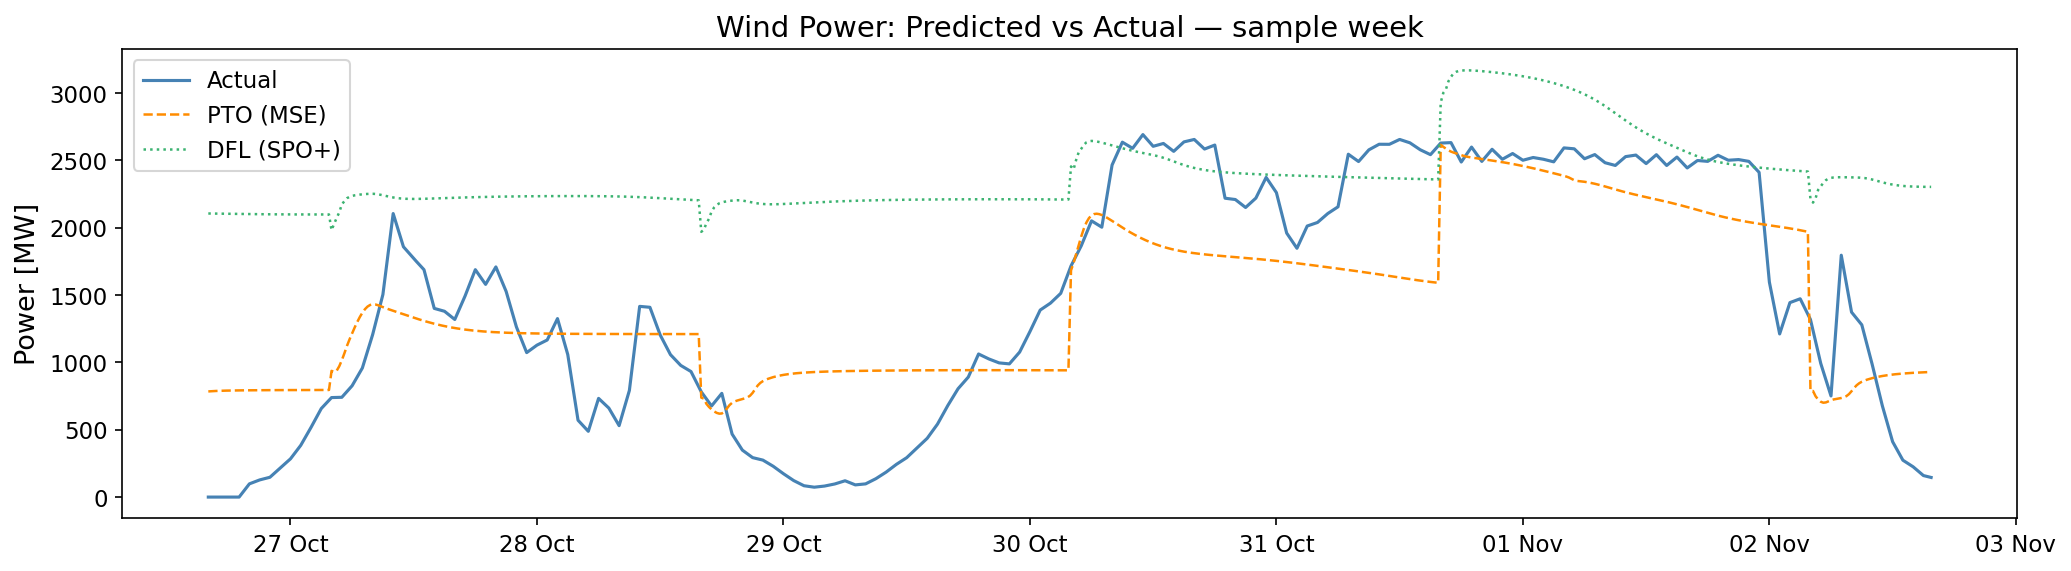

In [9]:
label = "Predicted vs Actual Wind Power (sample week)"
SAMPLE_START_local = SAMPLE_START
SAMPLE_END_local   = SAMPLE_END

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")


sample = pto.iloc[SAMPLE_START_local:SAMPLE_END_local]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample.index, sample["P_wind_actual"], label="Actual",        color="steelblue",      lw=1.5)
ax.plot(sample.index, sample["P_wind_pred"],   label="PTO (MSE)",     color="darkorange",     lw=1.2, linestyle="--")
if DFL_AVAILABLE:
    dfl_sample = dfl.iloc[SAMPLE_START_local:SAMPLE_END_local]
    ax.plot(dfl_sample.index, dfl_sample["P_wind_pred"], label="DFL (SPO+)", color="mediumseagreen", lw=1.2, linestyle=":")
ax.set_title("Wind Power: Predicted vs Actual — sample week")
ax.set_ylabel("Power [MW]")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.legend()
plt.tight_layout()
plt.show()

### PTO vs DFL Forecast Comparison


   PTO vs DFL Forecast Comparison
  -> Saved pto_vs_dfl_forecast_comparison-3gw_baseline.pdf


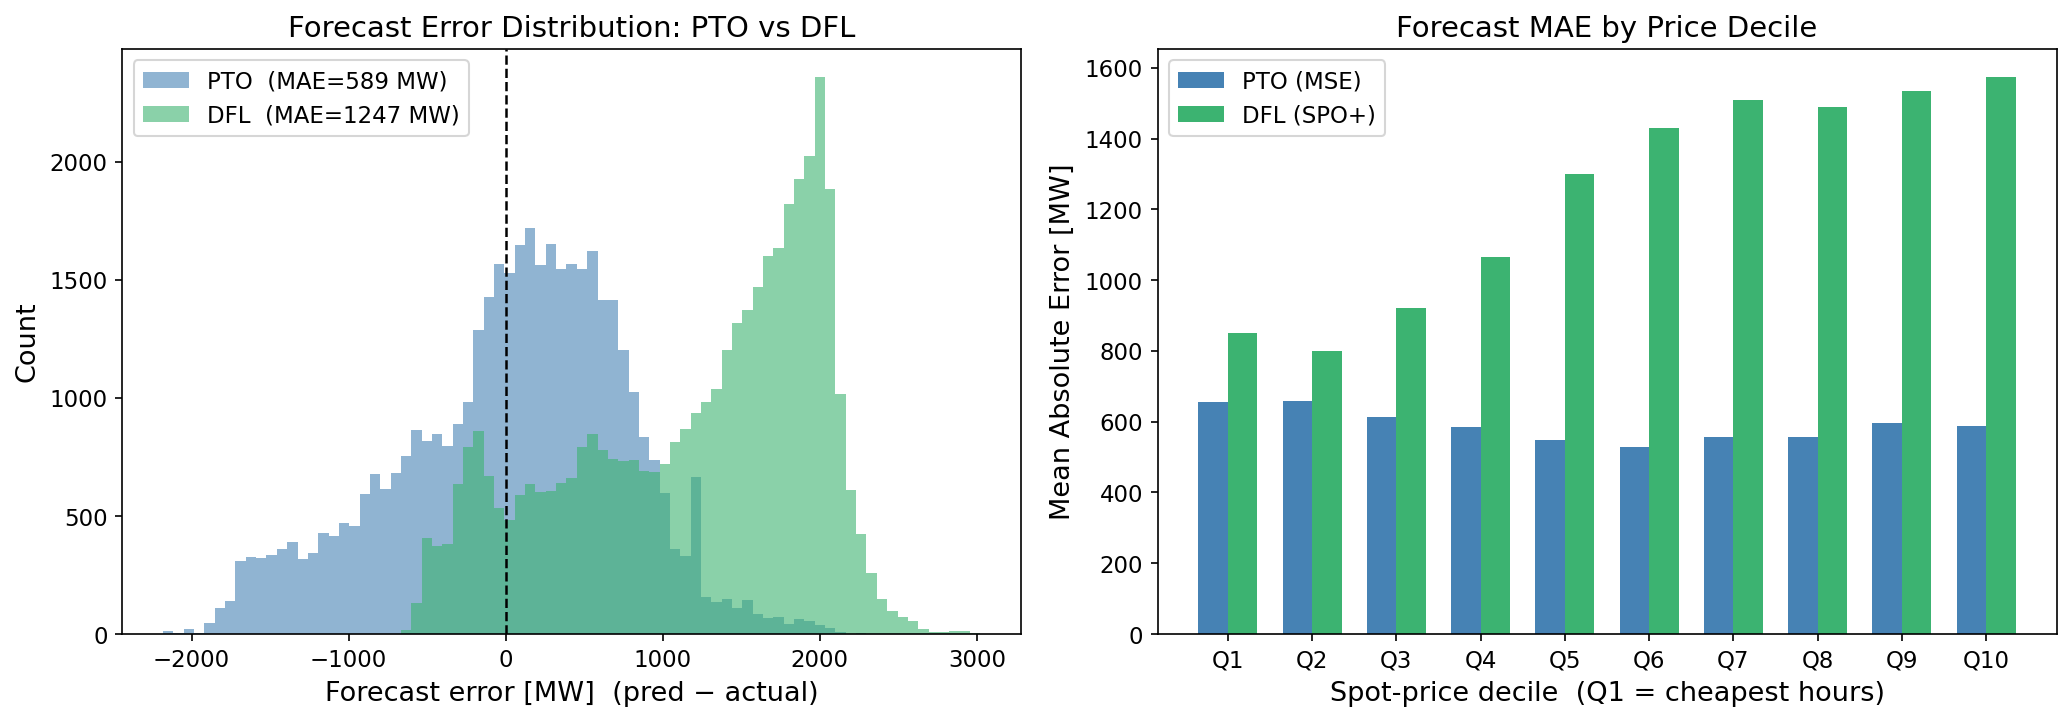

In [10]:
label = " PTO vs DFL Forecast Comparison"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")

if not DFL_AVAILABLE:
    print("DFL not available — skipping. Run `python main.py --dfl` first.")
else:
    pto_errors = pred    - actual
    dfl_errors = dfl_pred - dfl_actual

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    
    ax = axes[0]
    lo = min(pto_errors.min(), dfl_errors.min())
    hi = max(pto_errors.max(), dfl_errors.max())
    bins = np.linspace(lo, hi, 80)
    ax.hist(pto_errors, bins=bins, alpha=0.6, color="steelblue",
            label=f"PTO  (MAE={pto_errors.abs().mean():.0f} MW)")
    ax.hist(dfl_errors, bins=bins, alpha=0.6, color="mediumseagreen",
            label=f"DFL  (MAE={dfl_errors.abs().mean():.0f} MW)")
    ax.axvline(0, color="black", lw=1.2, linestyle="--")
    ax.set_xlabel("Forecast error [MW]  (pred − actual)")
    ax.set_ylabel("Count")
    ax.set_title("Forecast Error Distribution: PTO vs DFL")
    ax.legend()

  
    ax = axes[1]
    df_q = pd.DataFrame({
        "price":   prices.values,
        "mae_pto": pto_errors.abs().values,
        "mae_dfl": dfl_errors.abs().values,
    })
    df_q["decile"] = pd.qcut(df_q["price"], q=10, labels=False)
    grp = df_q.groupby("decile")[["mae_pto", "mae_dfl"]].mean()

    x = np.arange(len(grp))
    w = 0.35
    ax.bar(x - w/2, grp["mae_pto"], w, color="steelblue",      label="PTO (MSE)")
    ax.bar(x + w/2, grp["mae_dfl"], w, color="mediumseagreen", label="DFL (SPO+)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"Q{i+1}" for i in range(len(grp))])
    ax.set_xlabel("Spot-price decile  (Q1 = cheapest hours)")
    ax.set_ylabel("Mean Absolute Error [MW]")
    ax.set_title("Forecast MAE by Price Decile")
    ax.legend()

    plt.tight_layout()
    plt.show()


  Forecast Error by Wind Regime
  -> Saved forecast_error_by_wind_regime-3gw_baseline.pdf


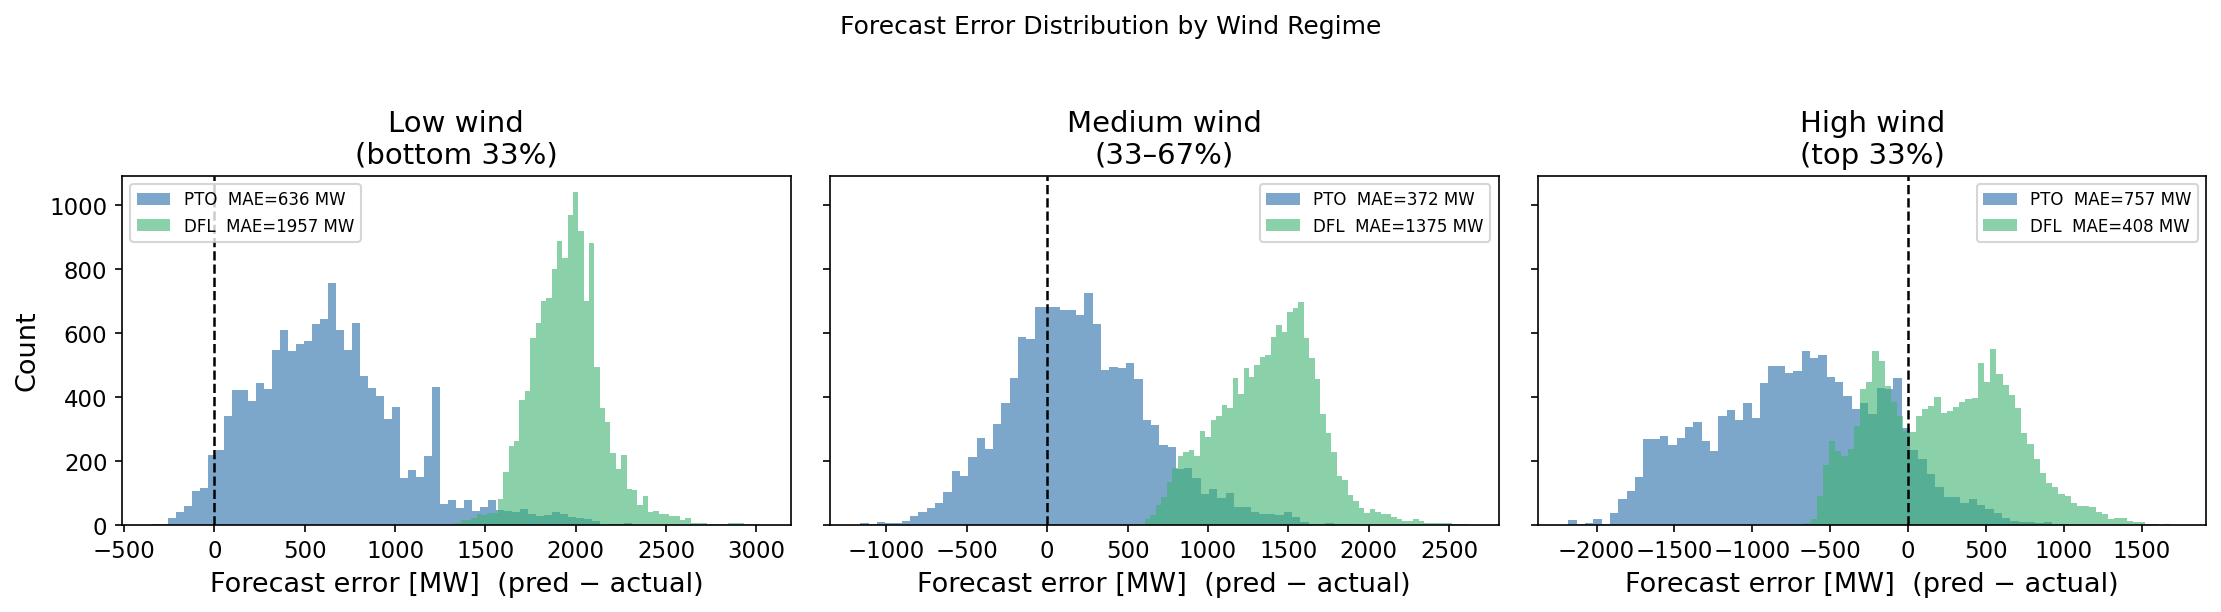

In [11]:
label = "Forecast Error by Wind Regime"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
bins = pd.qcut(actual, q=3, labels=["Low wind\n(bottom 33%)",
                                     "Medium wind\n(33–67%)",
                                     "High wind\n(top 33%)"])

for ax, regime in zip(axes, bins.unique().sort_values()):
    mask = bins == regime
    err_pto = errors[mask]
    ax.hist(err_pto, bins=60, color="steelblue", alpha=0.7, label=f"PTO  MAE={err_pto.abs().mean():.0f} MW")
    if DFL_AVAILABLE:
        _dfl_common = actual.index.intersection(dfl_actual.index)
        _bins_dfl = pd.qcut(actual.loc[_dfl_common], q=3,
                       labels=["Low wind\n(bottom 33%)", "Medium wind\n(33–67%)", "High wind\n(top 33%)"])
        _mask_dfl = _bins_dfl == regime
        err_dfl = (dfl_pred.loc[_dfl_common] - dfl_actual.loc[_dfl_common])[_mask_dfl]
        ax.hist(err_dfl, bins=60, color="mediumseagreen", alpha=0.6,
                label=f"DFL  MAE={err_dfl.abs().mean():.0f} MW")
    ax.axvline(0, color="black", lw=1.2, linestyle="--")
    ax.set_title(str(regime))
    ax.set_xlabel("Forecast error [MW]  (pred − actual)")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Count")
plt.suptitle("Forecast Error Distribution by Wind Regime", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## Oracle 




  Oracle Monthly Revenue Decomposition
  -> Saved oracle_monthly_revenue_decomposition-3gw_baseline.pdf


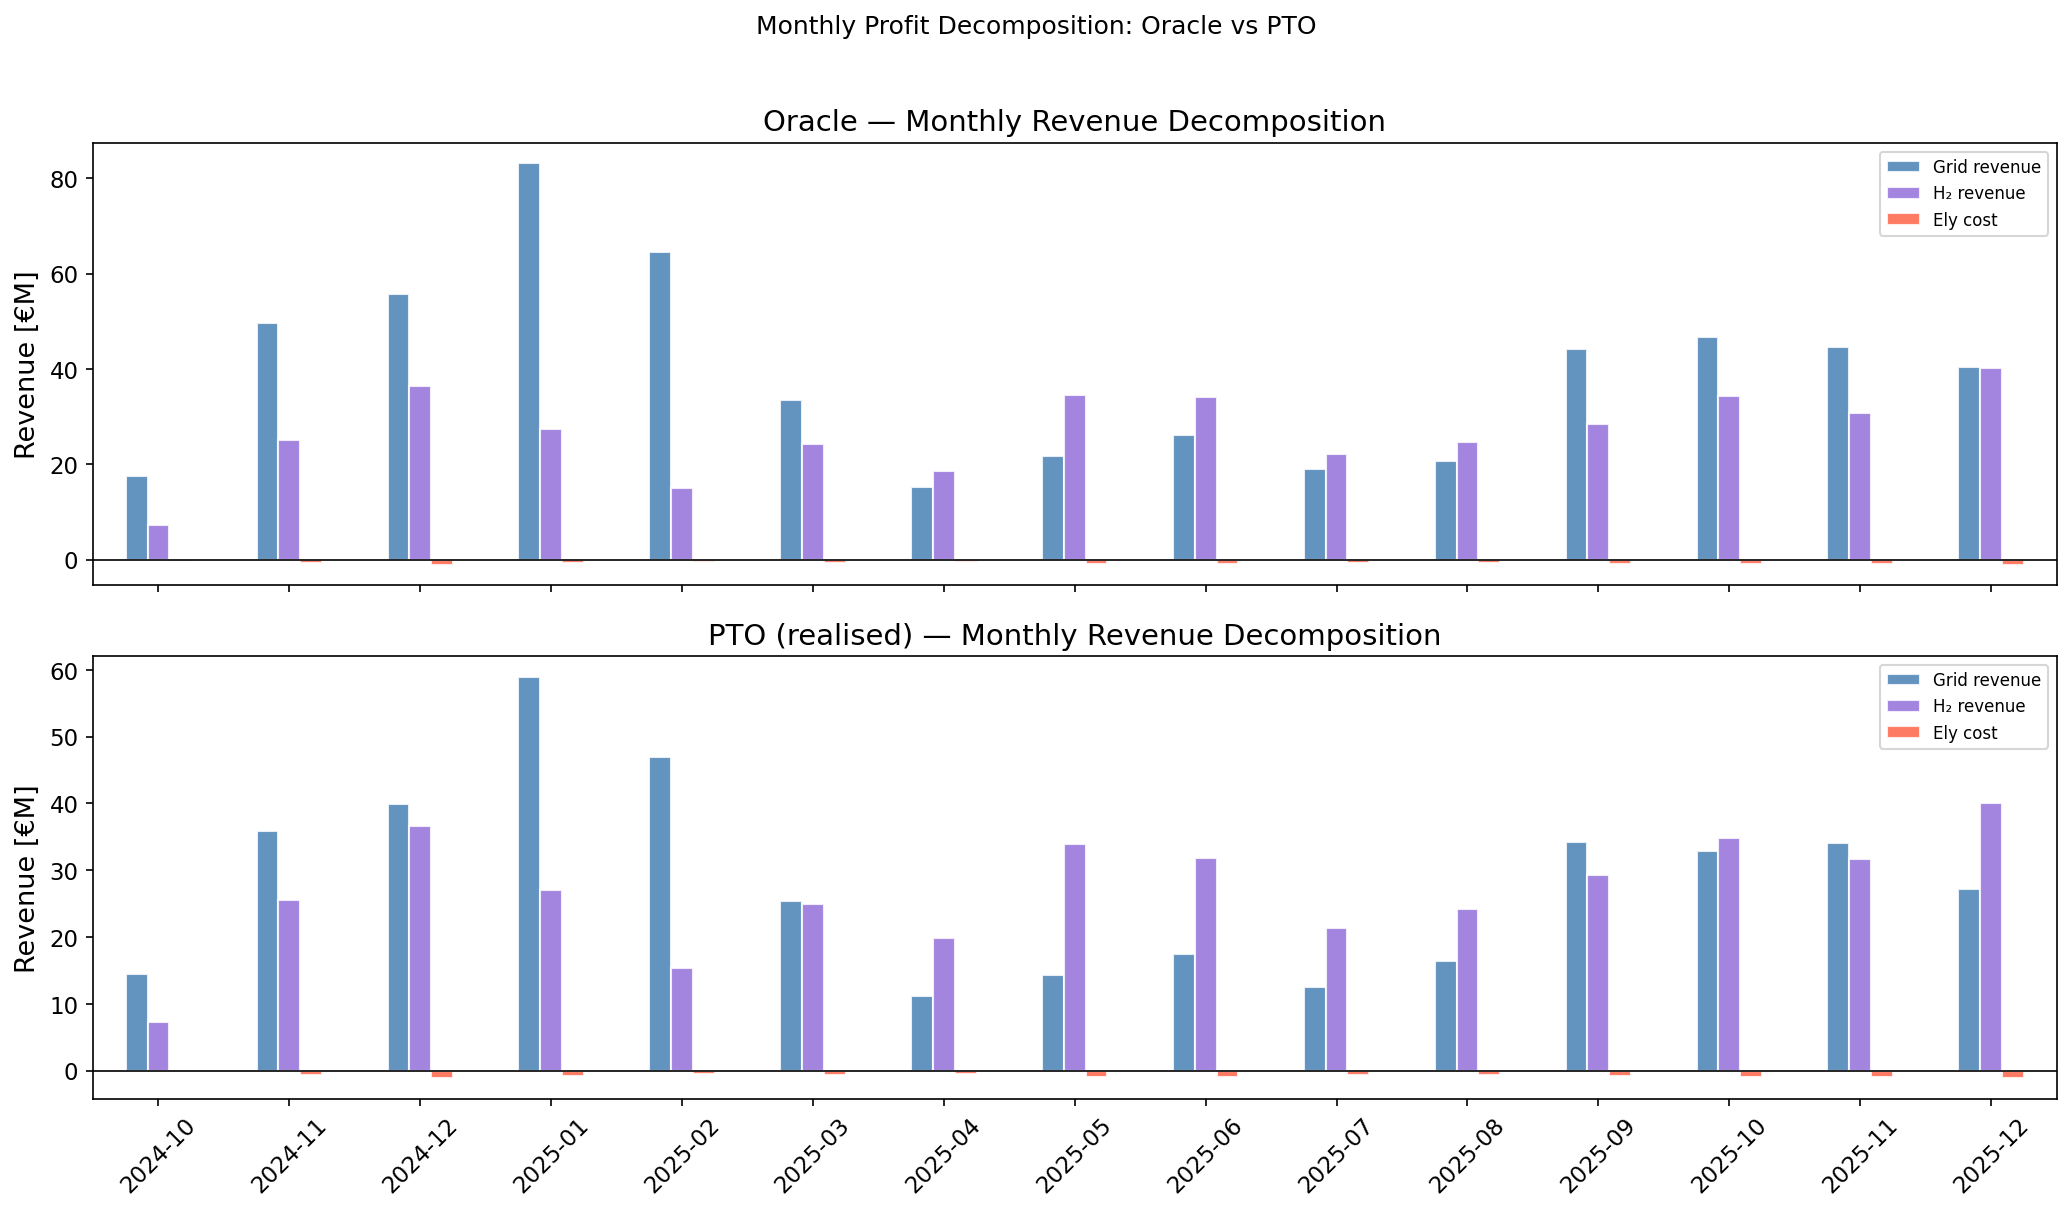

In [12]:
label = "Oracle Monthly Revenue Decomposition"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")


from scenarios import find_scenario as _fs_mo
from optimization import pi_H2 as _pi_H2_def_mo, C_ELY, C_BAT, C_CURT
_sc_mo   = _fs_mo(SCENARIO) if SCENARIO else {}
_pi_H2_mo = _sc_mo.get("pi_H2", _pi_H2_def_mo)
DELTA_T = 0.25

def monthly_revenue(df, use_realized=False):
    pg = df["P_grid_realized"] if (use_realized and "P_grid_realized" in df) else df["P_grid"]
    hs = df["H_sell_realized"] if (use_realized and "H_sell_realized" in df) else df["H_sell"]
    pe = df["P_ely_realized"]  if (use_realized and "P_ely_realized"  in df) else df["P_ely"]
    month = df.index.to_period("M").astype(str)
    grid = DELTA_T * (df["spot_price"] * pg).groupby(month).sum() / 1e6
    h2   = (_pi_H2_mo * hs).groupby(month).sum() / 1e6   # H_sell in MWh — no DELTA_T
    cost = DELTA_T * C_ELY * pe.groupby(month).sum() / 1e6
    return pd.DataFrame({"Grid revenue": grid, "H₂ revenue": h2, "Ely cost": -cost})

orc_monthly = monthly_revenue(oracle, use_realized=False)
pto_monthly = monthly_revenue(pto,    use_realized=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

orc_monthly[["Grid revenue", "H₂ revenue", "Ely cost"]].plot(
    kind="bar", ax=axes[0], color=["steelblue", "mediumpurple", "tomato"],
    edgecolor="white", alpha=0.85, grid=False)
axes[0].set_title("Oracle — Monthly Revenue Decomposition")
axes[0].set_ylabel("Revenue [\u20acM]"); axes[0].axhline(0, color="black", lw=0.8)
axes[0].tick_params(axis="x", rotation=45); axes[0].legend(fontsize=8)
axes[0].grid(False)

pto_monthly[["Grid revenue", "H₂ revenue", "Ely cost"]].plot(
    kind="bar", ax=axes[1], color=["steelblue", "mediumpurple", "tomato"],
    edgecolor="white", alpha=0.85, grid=False)
axes[1].set_title("PTO (realised) — Monthly Revenue Decomposition")
axes[1].set_ylabel("Revenue [\u20acM]"); axes[1].axhline(0, color="black", lw=0.8)
axes[1].tick_params(axis="x", rotation=45); axes[1].legend(fontsize=8)
axes[1].grid(False)

plt.suptitle("Monthly Profit Decomposition: Oracle vs PTO", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

## Seasonal Profit Decomposition


  Seasonal Profit Decomposition
  -> Saved seasonal_profit_decomposition-3gw_baseline.pdf


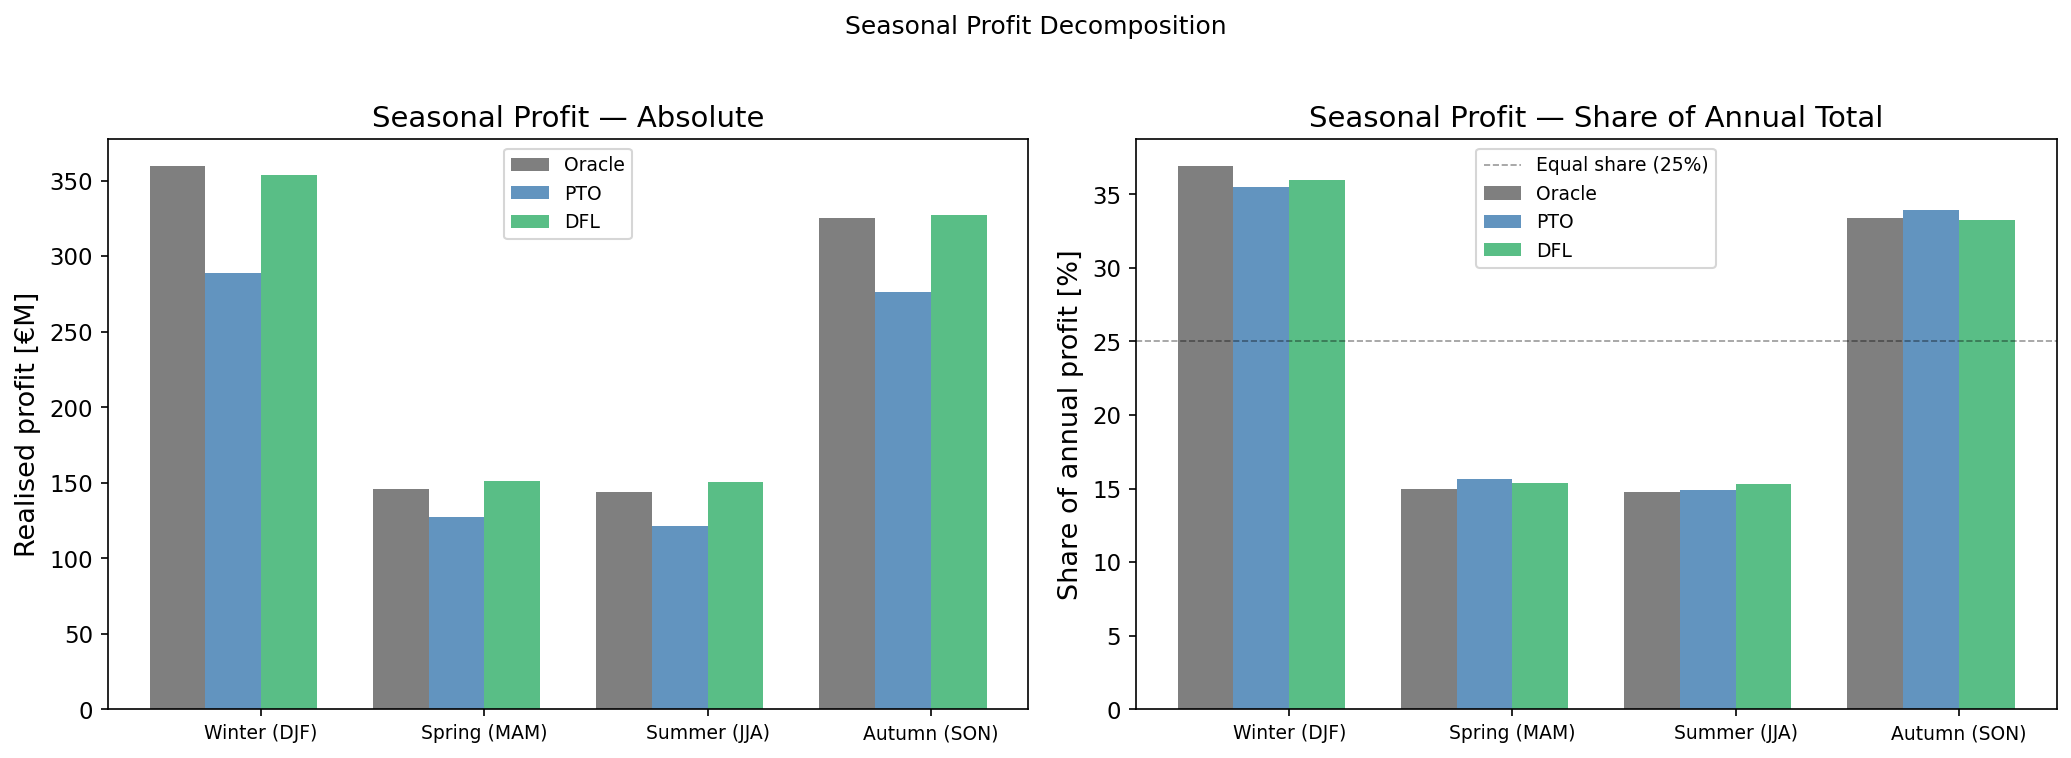


Seasonal profit [€M]:
              Oracle     PTO     DFL
Winter (DJF)  359.43  288.71  353.64
Spring (MAM)  145.66  127.41  151.37
Summer (JJA)  144.10  121.53  150.76
Autumn (SON)  325.08  276.43  326.93

Seasonal profit share [%]:
              Oracle   PTO   DFL
Winter (DJF)    36.9  35.5  36.0
Spring (MAM)    15.0  15.7  15.4
Summer (JJA)    14.8  14.9  15.3
Autumn (SON)    33.4  34.0  33.3


In [13]:
label = "Seasonal Profit Decomposition"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")


from scenarios import find_scenario as _fs
from optimization import pi_H2 as _pi_H2_def, C_ELY as _C_ELY_def
_sc_dict = _fs(SCENARIO) if SCENARIO else {}
_pi_H2   = _sc_dict.get('pi_H2', _pi_H2_def)
_C_ELY   = _sc_dict.get('C_ELY', _C_ELY_def)
DELTA_T  = 0.25

SEASONS = {
    "Winter (DJF)": [12, 1, 2],
    "Spring (MAM)": [3, 4, 5],
    "Summer (JJA)": [6, 7, 8],
    "Autumn (SON)": [9, 10, 11],
}

def seasonal_profit(df, use_realized=True):
    pg = df["P_grid_realized"] if (use_realized and "P_grid_realized" in df) else df["P_grid"]
    hs = df["H_sell_realized"] if (use_realized and "H_sell_realized" in df) else df["H_sell"]
    pe = df["P_ely_realized"]  if (use_realized and "P_ely_realized"  in df) else df["P_ely"]
   
    rev = DELTA_T * (df["spot_price"] * pg - _C_ELY * pe) + _pi_H2 * hs
    result = {}
    for name, months in SEASONS.items():
        mask = df.index.month.isin(months)
        result[name] = rev[mask].sum() / 1e6
    return result

seas_data = {
    "Oracle": seasonal_profit(oracle, use_realized=False),
    "PTO":    seasonal_profit(pto,    use_realized=True),
}
if DFL_AVAILABLE:
    seas_data["DFL"] = seasonal_profit(dfl, use_realized=True)

df_seas = pd.DataFrame(seas_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


ax = axes[0]
x = np.arange(4); w = 0.25
colors_m = {"Oracle": "dimgray", "DFL": "mediumseagreen", "PTO": "steelblue"}
for i, (method, vals) in enumerate(df_seas.items()):
    offset = (i - len(df_seas)/2 + 0.5) * w
    ax.bar(x + offset, vals, w, label=method, color=colors_m.get(method, "gray"), alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(df_seas.index, fontsize=9)
ax.set_ylabel("Realised profit [€M]")
ax.set_title("Seasonal Profit — Absolute")
ax.legend(fontsize=9)


ax = axes[1]
df_seas_pct = df_seas.div(df_seas.sum()) * 100
for i, (method, vals) in enumerate(df_seas_pct.items()):
    offset = (i - len(df_seas_pct)/2 + 0.5) * w
    ax.bar(x + offset, vals, w, label=method, color=colors_m.get(method, "gray"), alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(df_seas_pct.index, fontsize=9)
ax.set_ylabel("Share of annual profit [%]")
ax.set_title("Seasonal Profit — Share of Annual Total")
ax.axhline(25, color="black", lw=0.8, linestyle="--", alpha=0.4, label="Equal share (25%)")
ax.legend(fontsize=9)

plt.suptitle("Seasonal Profit Decomposition", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

print("\nSeasonal profit [€M]:")
print(df_seas.round(2).to_string())
print("\nSeasonal profit share [%]:")
print(df_seas_pct.round(1).to_string())



  Oracle Dispatch Logic
  -> Saved oracle_dispatch_logic-3gw_baseline.pdf


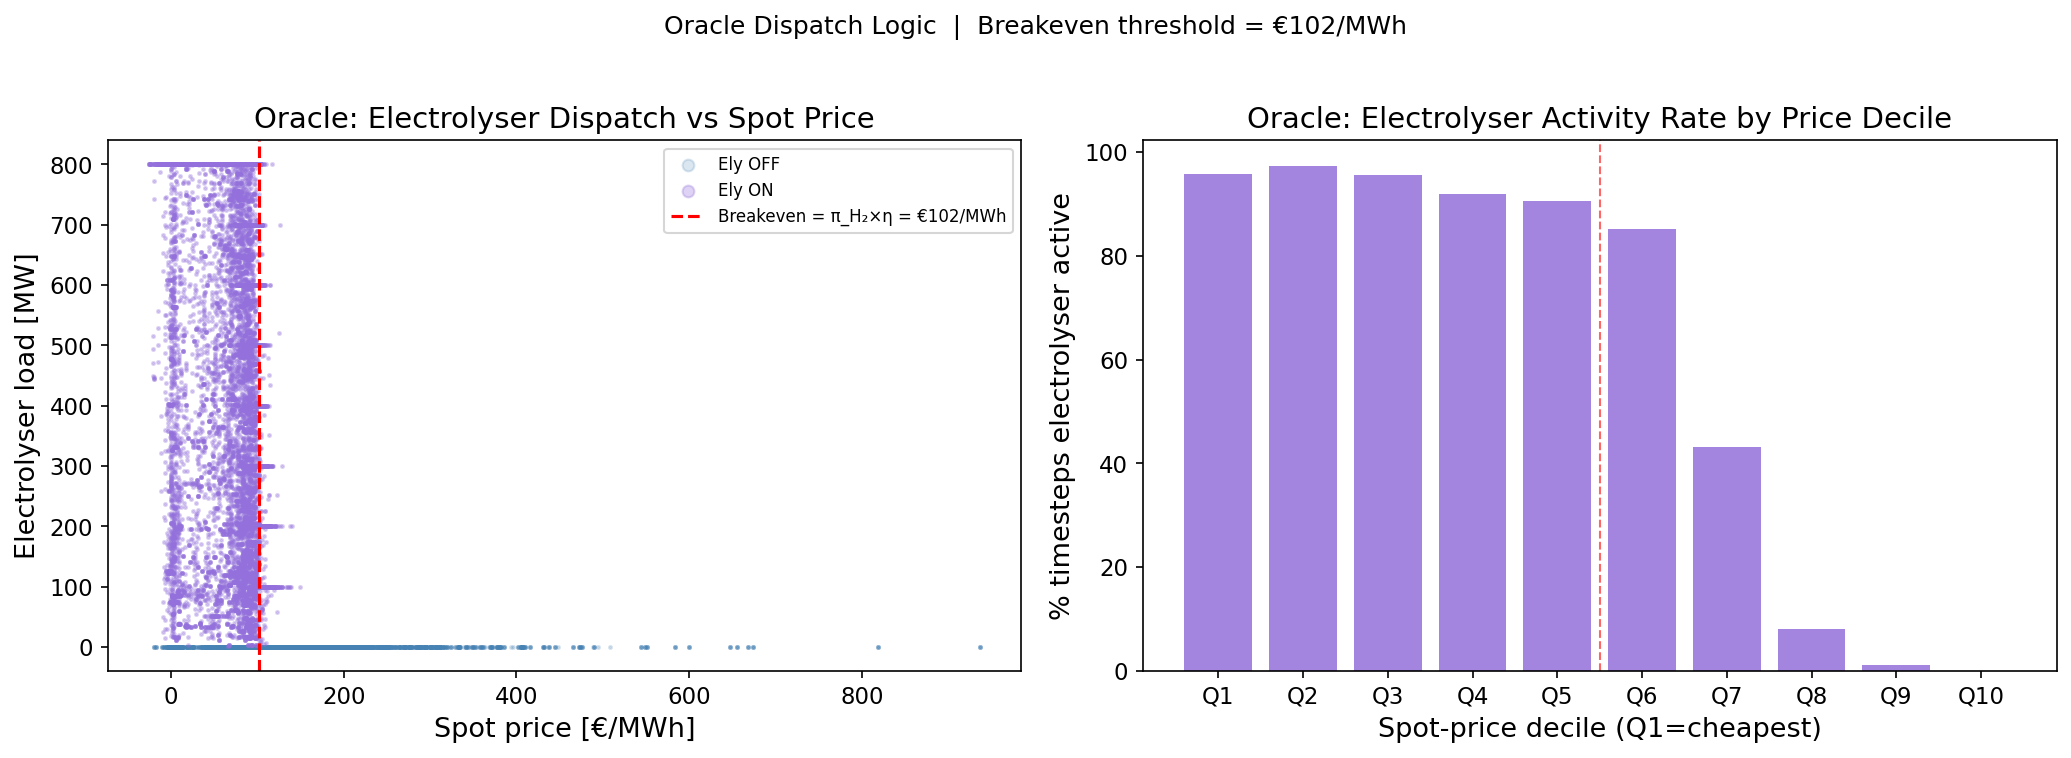

Breakeven: π_H₂=150 €/MWh_H₂ × η_ely=0.68 = 102.0 €/MWh


In [14]:
label = "Oracle Dispatch Logic"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")


from scenarios import find_scenario
from optimization import pi_H2
scen_cfg  = find_scenario(SCENARIO) if SCENARIO else {}
ETA_ELY   = scen_cfg.get("ETA_ELY", 0.68)
_pi_H2    = scen_cfg.get("pi_H2",   pi_H2)
threshold = _pi_H2 * ETA_ELY   

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


ax = axes[0]
ely_on  = oracle["P_ely"] > 1
ax.scatter(oracle.loc[~ely_on, "spot_price"], oracle.loc[~ely_on, "P_ely"],
           s=2, alpha=0.2, color="steelblue", label="Ely OFF")
ax.scatter(oracle.loc[ely_on,  "spot_price"], oracle.loc[ely_on,  "P_ely"],
           s=2, alpha=0.3, color="mediumpurple", label="Ely ON")
ax.axvline(threshold, color="red", lw=1.5, linestyle="--",
           label=f"Breakeven = π_H₂×η = €{threshold:.0f}/MWh")
ax.set_xlabel("Spot price [€/MWh]")
ax.set_ylabel("Electrolyser load [MW]")
ax.set_title("Oracle: Electrolyser Dispatch vs Spot Price")
ax.legend(fontsize=8, markerscale=4)


ax = axes[1]
price_d = pd.qcut(oracle["spot_price"], q=10, labels=[f"Q{i+1}" for i in range(10)])
ely_rate = oracle["P_ely"].gt(1).groupby(price_d).mean() * 100
ax.bar(range(10), ely_rate, color="mediumpurple", alpha=0.85)
ax.set_xticks(range(10))
ax.set_xticklabels([f"Q{i+1}" for i in range(10)])
ax.set_xlabel("Spot-price decile (Q1=cheapest)")
ax.set_ylabel("% timesteps electrolyser active")
ax.set_title("Oracle: Electrolyser Activity Rate by Price Decile")
ax.axvline(4.5, color="red", lw=1, linestyle="--", alpha=0.6)

plt.suptitle(f"Oracle Dispatch Logic  |  Breakeven threshold = €{threshold:.0f}/MWh", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()
print(f"Breakeven: π_H₂={_pi_H2} €/MWh_H₂ × η_ely={ETA_ELY} = {threshold:.1f} €/MWh")

## PTO vs DFL: Decision-Level Comparison




  Regret Heatmap: Revenue Gap vs Oracle
  -> Saved regret_heatmap-revenue_gap_vs_oracle-3gw_baseline.pdf


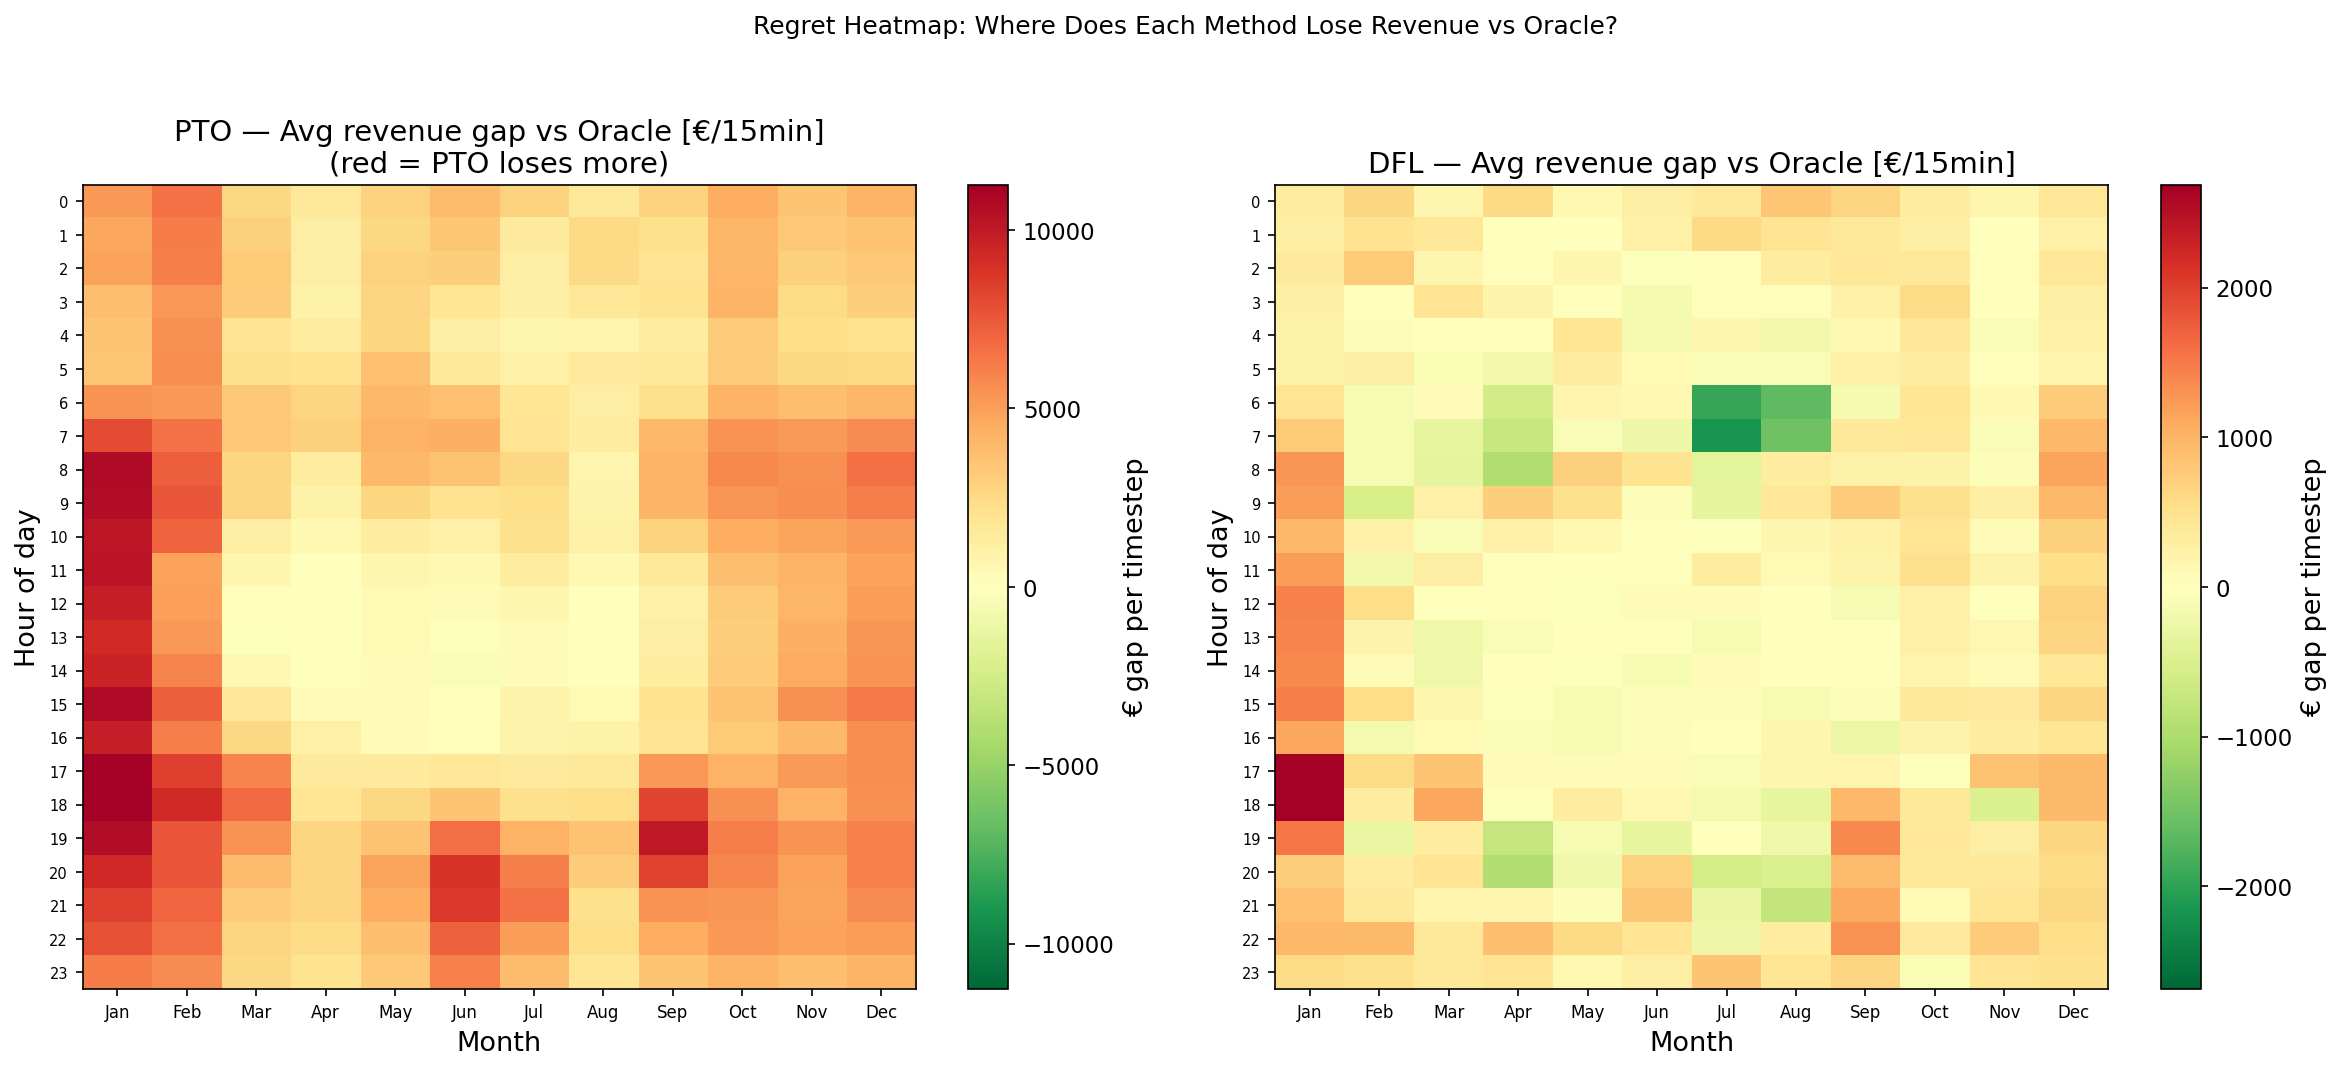

In [15]:
label = "Regret Heatmap: Revenue Gap vs Oracle"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")


common = pto.index.intersection(oracle.index)
pto_c  = pto.loc[common]
orc_c  = oracle.loc[common]

orc_rev_t  = DELTA_T * orc_c["spot_price"] * orc_c["P_grid"]
pto_rev_t  = DELTA_T * pto_c["spot_price"] * pto_c["P_grid_realized"]
pto_gap_t  = orc_rev_t - pto_rev_t   

df_gap = pd.DataFrame({
    "gap":   pto_gap_t.values,
    "hour":  common.hour,
    "month": common.month,
}, index=common)

pivot_pto = df_gap.pivot_table(values="gap", index="hour", columns="month", aggfunc="mean")
pivot_pto.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

n_plots = 2 if DFL_AVAILABLE else 1
fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 7))
if n_plots == 1: axes = [axes]

import matplotlib.colors as mcolors
vmax = max(abs(pivot_pto.values).max(), 1)

im = axes[0].imshow(pivot_pto, aspect="auto", cmap="RdYlGn_r", vmin=-vmax, vmax=vmax)
axes[0].set_xticks(range(12)); axes[0].set_xticklabels(pivot_pto.columns, fontsize=8)
axes[0].set_yticks(range(24)); axes[0].set_yticklabels(range(24), fontsize=7)
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Hour of day")
axes[0].set_title("PTO — Avg revenue gap vs Oracle [€/15min]\n(red = PTO loses more)")
plt.colorbar(im, ax=axes[0], label="€ gap per timestep")

if DFL_AVAILABLE:
    _dfl_common = common.intersection(dfl.index)
    dfl_c = dfl.loc[_dfl_common]
    dfl_rev_t = DELTA_T * dfl_c["spot_price"] * dfl_c["P_grid_realized"]
    dfl_gap_t = orc_rev_t - dfl_rev_t
    df_gap_dfl = pd.DataFrame({
        "gap": dfl_gap_t.values, "hour": common.hour, "month": common.month
    }, index=common)
    pivot_dfl = df_gap_dfl.pivot_table(values="gap", index="hour", columns="month", aggfunc="mean")
    pivot_dfl.columns = pivot_pto.columns
    vmax2 = max(abs(pivot_dfl.values).max(), 1)
    im2 = axes[1].imshow(pivot_dfl, aspect="auto", cmap="RdYlGn_r", vmin=-vmax2, vmax=vmax2)
    axes[1].set_xticks(range(12)); axes[1].set_xticklabels(pivot_dfl.columns, fontsize=8)
    axes[1].set_yticks(range(24)); axes[1].set_yticklabels(range(24), fontsize=7)
    axes[1].set_xlabel("Month"); axes[1].set_ylabel("Hour of day")
    axes[1].set_title("DFL — Avg revenue gap vs Oracle [€/15min]")
    plt.colorbar(im2, ax=axes[1], label="€ gap per timestep")

plt.suptitle("Regret Heatmap: Where Does Each Method Lose Revenue vs Oracle?",
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


  Statistical Significance: DFL vs PTO Profit
  -> Saved statistical_significance-dfl_vs_pto_profit-3gw_baseline.pdf


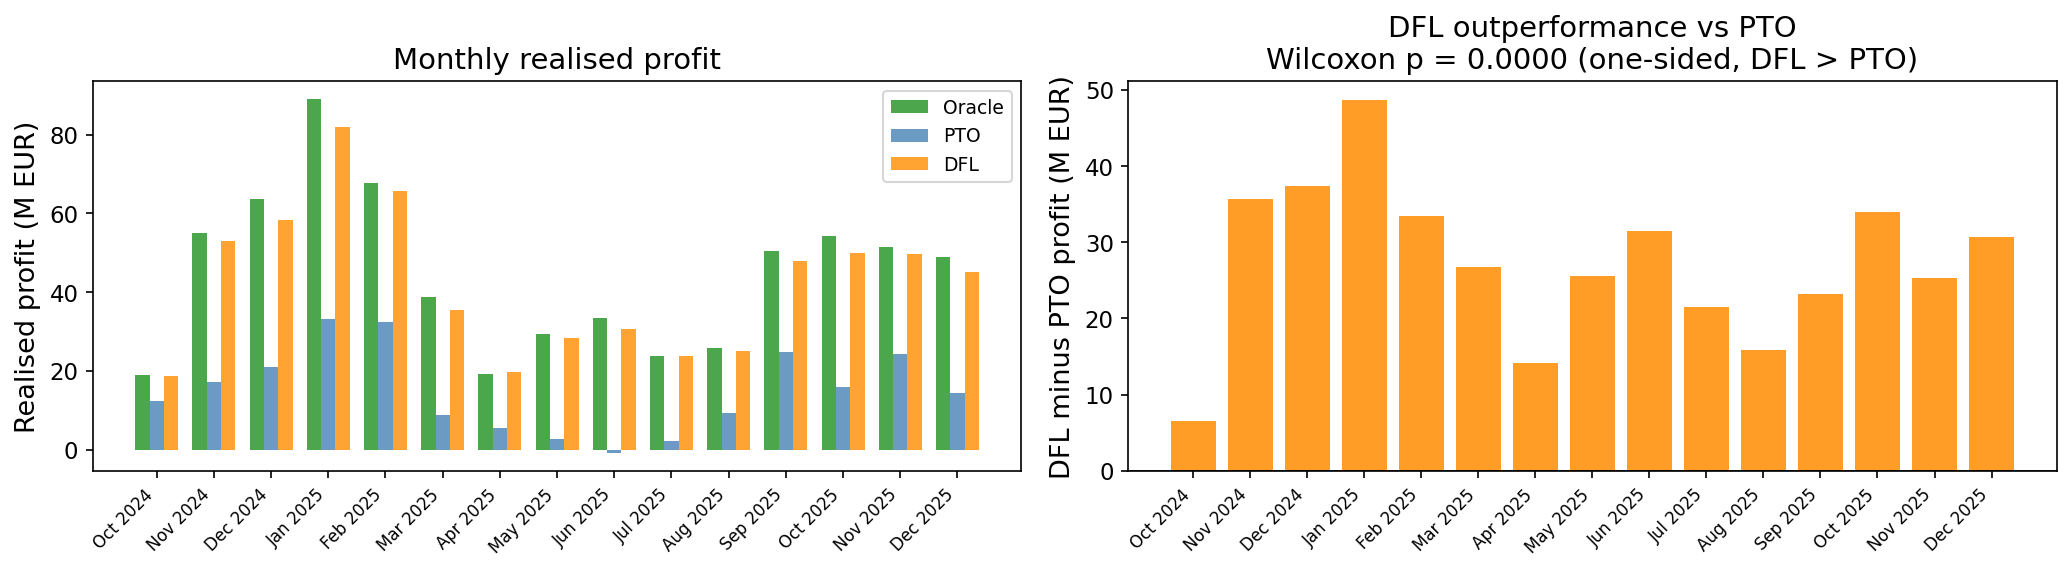

Months where DFL > PTO : 15/15
Median monthly gap     : +26.82 M EUR
Wilcoxon statistic     : 120,  p-value = 0.0000
Result: DFL significantly outperforms PTO (p<0.05)


In [16]:
label = "Statistical Significance: DFL vs PTO Profit"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")



if not DFL_AVAILABLE:
    print('DFL not available - skipping significance test.')
else:
    from scipy import stats
    DELTA_T = 0.25
    from scenarios import find_scenario as _fs2
    from optimization import pi_H2 as _pi_H2d, C_ELY as _C_ELYd, C_BAT as _C_BATd, C_CURT as _C_CURTd
    sc = _fs2(SCENARIO) if SCENARIO else {}
    _pi_H2  = sc.get('pi_H2',  _pi_H2d)
    _C_ELY  = sc.get('C_ELY',  _C_ELYd)
    _C_BAT  = sc.get('C_BAT',  _C_BATd)
    _C_CURT = sc.get('C_CURT', _C_CURTd)

    _pto_idx    = pto.index[~pto.index.duplicated()]
    _dfl_idx    = dfl.index[~dfl.index.duplicated()]
    _oracle_idx = oracle.index[~oracle.index.duplicated()]
    common = _pto_idx.intersection(_dfl_idx).intersection(_oracle_idx)

    if len(common) == 0:
        print('No overlapping timestamps between PTO, DFL, and Oracle — skipping.')
    else:
        p = pto.loc[common]
        d = dfl.loc[common]
        o = oracle.loc[common]

        def ts_profit(df, realized=True):
            g_col  = 'P_grid_realized' if (realized and 'P_grid_realized' in df.columns) else 'P_grid'
            e_col  = 'P_ely_realized'  if (realized and 'P_ely_realized'  in df.columns) else 'P_ely'
            ch_col = 'P_ch_realized'   if (realized and 'P_ch_realized'   in df.columns) else 'P_ch'
            hs_col = 'H_sell_realized' if (realized and 'H_sell_realized' in df.columns) else 'H_sell'
            cu_col = 'P_curt_realized' if (realized and 'P_curt_realized' in df.columns) else 'P_curt'
            return DELTA_T * (
                df['spot_price'] * df[g_col]
                + _pi_H2  * df[hs_col]
                - _C_ELY  * df[e_col]
                - _C_BAT  * (df[ch_col] + df['P_dis'])
                - _C_CURT * df[cu_col]
            )

        r_pto    = ts_profit(p)
        r_dfl    = ts_profit(d)
        r_oracle = ts_profit(o, realized=False)

        month_pto    = r_pto.resample('ME').sum() / 1e6
        month_dfl    = r_dfl.resample('ME').sum() / 1e6
        month_oracle = r_oracle.resample('ME').sum() / 1e6
        cm = month_pto.index.intersection(month_dfl.index)
        month_pto    = month_pto.loc[cm]
        month_dfl    = month_dfl.loc[cm]
        month_oracle = month_oracle.loc[cm]

        diff = (month_dfl - month_pto).values


        nonzero_diff = diff[diff != 0]
        if len(nonzero_diff) < 2:
            print(f'Not enough non-zero monthly differences ({len(nonzero_diff)}) for Wilcoxon test.')
            pval = float('nan')
            stat_w = float('nan')
        else:
            try:
                stat_w, pval = stats.wilcoxon(diff, alternative='greater')
            except ValueError as e:
                print(f'Wilcoxon test failed: {e}')
                pval = float('nan')
                stat_w = float('nan')

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        ax = axes[0]
        x = np.arange(len(cm))
        ax.bar(x - 0.25, month_oracle.values, 0.25, label='Oracle', alpha=0.7, color='green')
        ax.bar(x,        month_pto.values,    0.25, label='PTO',    alpha=0.8, color='steelblue')
        ax.bar(x + 0.25, month_dfl.values,    0.25, label='DFL',    alpha=0.8, color='darkorange')
        ax.set_xticks(x)
        ax.set_xticklabels([m.strftime('%b %Y') for m in cm], rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Realised profit (M EUR)')
        ax.set_title('Monthly realised profit')
        ax.legend(fontsize=9)

        ax2 = axes[1]
        bar_colors = ['darkorange' if v > 0 else 'steelblue' for v in diff]
        ax2.bar(x, diff, color=bar_colors, alpha=0.85)
        ax2.axhline(0, color='black', lw=0.8)
        ax2.set_xticks(x)
        ax2.set_xticklabels([m.strftime('%b %Y') for m in cm], rotation=45, ha='right', fontsize=8)
        ax2.set_ylabel('DFL minus PTO profit (M EUR)')
        pval_str = f'{pval:.4f}' if not np.isnan(pval) else 'n/a'
        ax2.set_title(f'DFL outperformance vs PTO\nWilcoxon p = {pval_str} (one-sided, DFL > PTO)')

        fig.tight_layout()
        plt.show()

        n_wins = int((diff > 0).sum())
        print(f'Months where DFL > PTO : {n_wins}/{len(diff)}')
        print(f'Median monthly gap     : {np.median(diff):+.2f} M EUR')
        if not np.isnan(stat_w):
            print(f'Wilcoxon statistic     : {stat_w:.0f},  p-value = {pval:.4f}')
            sig = pval < 0.05
            print(f'Result: {"DFL significantly outperforms PTO (p<0.05)" if sig else "No statistically significant outperformance (p>=0.05)"}')

###  Optimisation Evaluation (PTO Dispatch)


  PTO Dispatch Decisions: Sample Week
  -> Saved pto_dispatch_decisions-sample_week-3gw_baseline.pdf


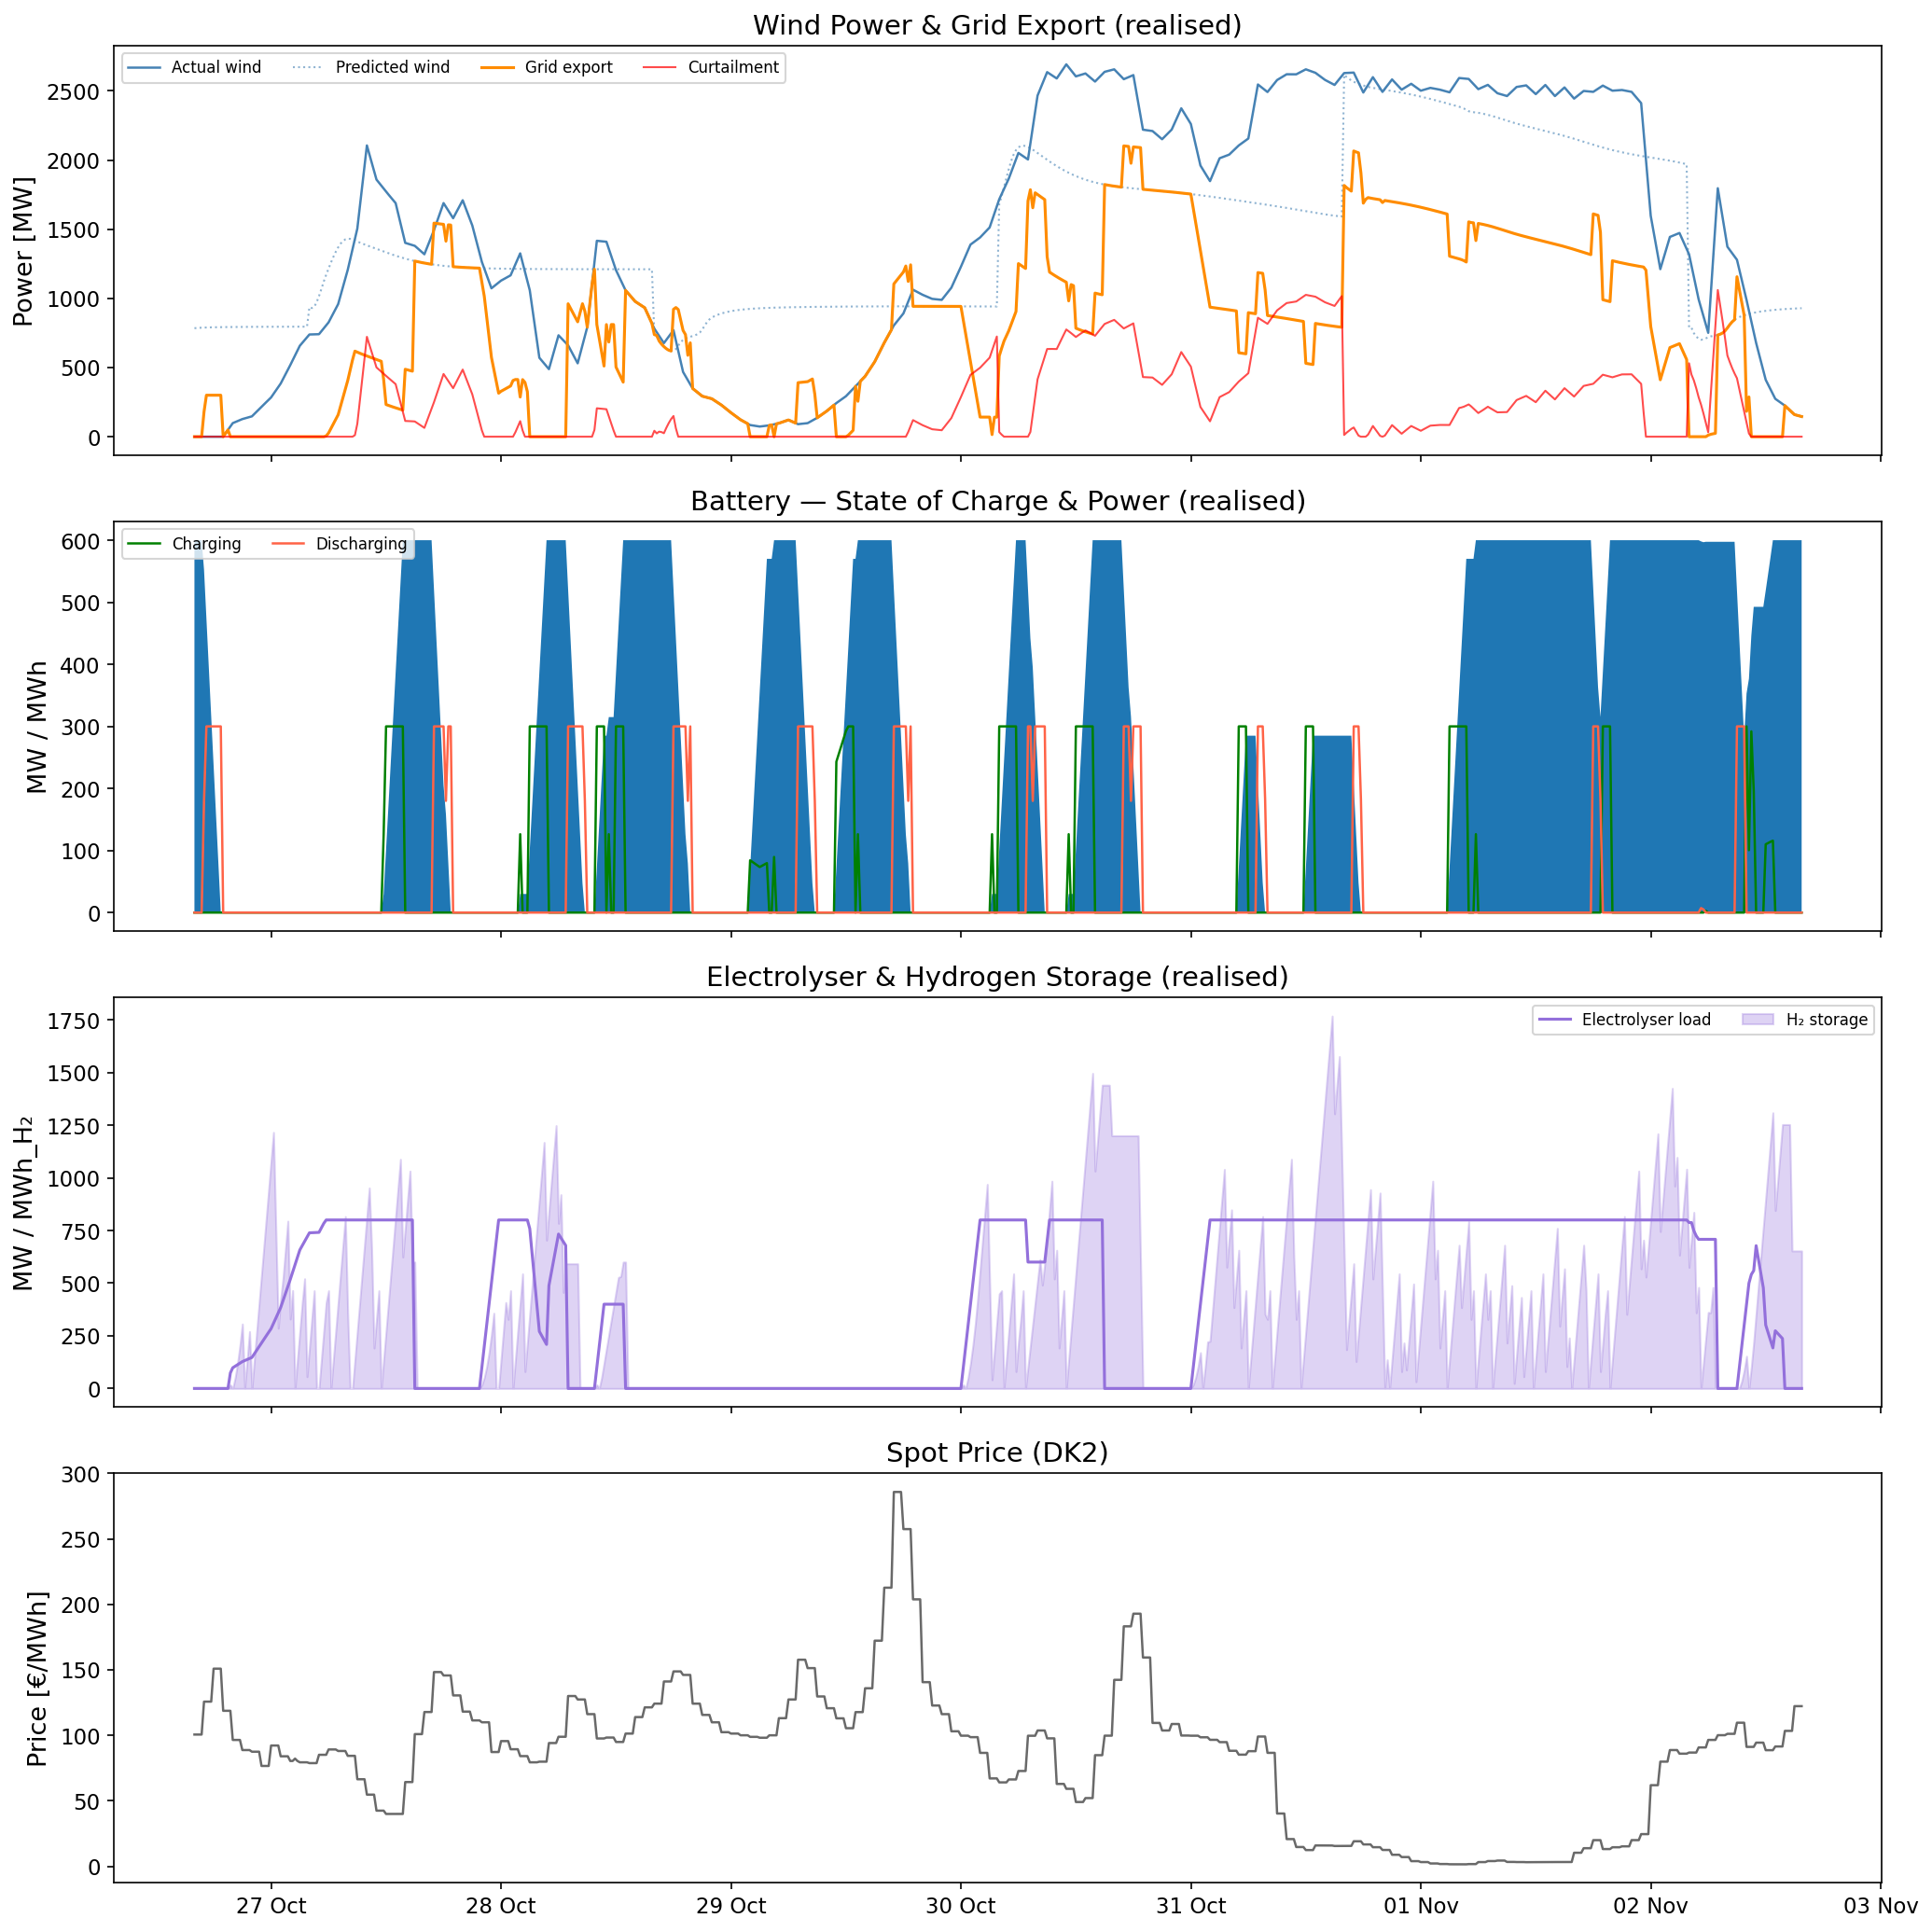

In [17]:
label = "PTO Dispatch Decisions: Sample Week"
SAMPLE_START_local = SAMPLE_START
SAMPLE_END_local   = SAMPLE_END

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")

 
s = pto.iloc[SAMPLE_START_local:SAMPLE_END_local]

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)


ax = axes[0]
ax.plot(s.index, s["P_wind_actual"], color="steelblue",  lw=1.2, label="Actual wind")
ax.plot(s.index, s["P_wind_pred"],   color="steelblue",  lw=1,   linestyle=":", alpha=0.6, label="Predicted wind")
ax.plot(s.index, s["P_grid_realized"],        color="darkorange", lw=1.5, label="Grid export")
ax.plot(s.index, s["P_curt_realized"],        color="red",        lw=1,   label="Curtailment", alpha=0.7)
ax.set_ylabel("Power [MW]")
ax.set_title("Wind Power & Grid Export (realised)")
ax.legend(ncol=4, fontsize=8)


ax = axes[1]
ax.fill_between(s.index, s["E_bat"]) 
ax.plot(s.index, s["P_ch_realized"],  color="green",  lw=1.2, label="Charging")
ax.plot(s.index, s["P_dis"], color="tomato", lw=1.2, label="Discharging")
ax.set_ylabel("MW / MWh")
ax.set_title("Battery — State of Charge & Power (realised)")
ax.legend(ncol=3, fontsize=8)


ax = axes[2]
ax.plot(s.index, s["P_ely_realized"], color="mediumpurple", lw=1.5, label="Electrolyser load")
ax.fill_between(s.index, s["E_H2"], alpha=0.3, color="mediumpurple", label="H₂ storage")
ax.set_ylabel("MW / MWh_H₂")
ax.set_title("Electrolyser & Hydrogen Storage (realised)")
ax.legend(ncol=2, fontsize=8)


ax = axes[3]
ax.plot(s.index, s["spot_price"], color="dimgray", lw=1.2)
ax.set_ylabel("Price [€/MWh]")
ax.set_title("Spot Price (DK2)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

plt.tight_layout()
plt.show()


  Revenue Breakdown: PTO vs DFL vs Oracle
  -> Saved revenue_breakdown-pto_vs_dfl_vs_oracle-3gw_baseline.pdf


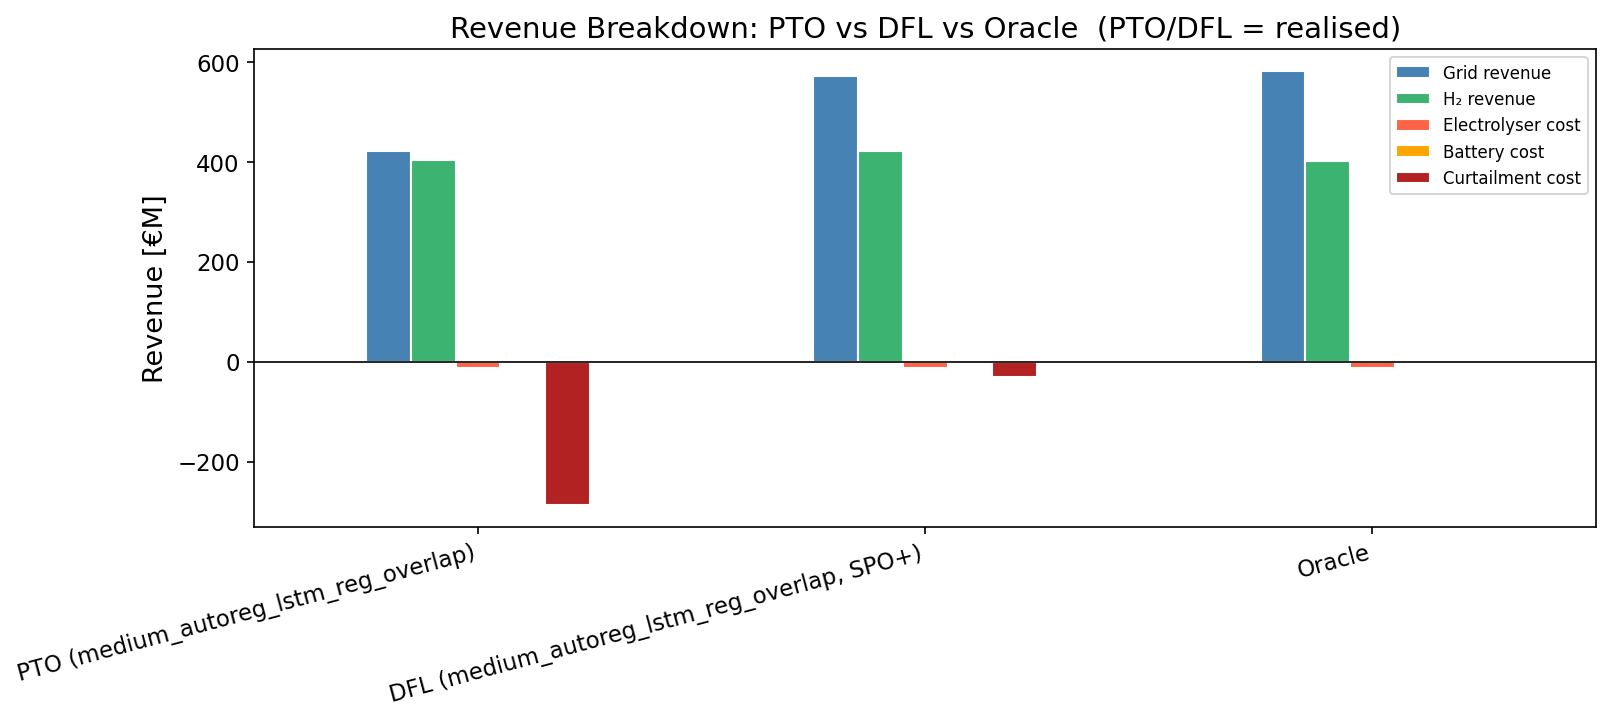

                   PTO (medium_autoreg_lstm_reg_overlap)  DFL (medium_autoreg_lstm_reg_overlap, SPO+)      Oracle
Grid revenue                                  422.077469                                   571.939386  582.961653
H₂ revenue                                    403.549033                                   422.703414  403.159856
Electrolyser cost                             -11.537603                                   -11.939709  -11.857643
Battery cost                                   -1.568466                                    -1.690610   -1.582809
Curtailment cost                             -286.626279                                   -30.421469   -0.000000


In [18]:
label = "Revenue Breakdown: PTO vs DFL vs Oracle"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")


DELTA_T = 0.25
from scenarios import find_scenario as _fs_bd
from optimization import pi_H2 as _pi_H2_def, C_ELY, C_BAT, C_CURT, C_RU
_sc_bd    = _fs_bd(SCENARIO) if SCENARIO else {}
_pi_H2_bd = _sc_bd.get("pi_H2", _pi_H2_def)  #

def revenue_breakdown(df, label, realized=True):
    """Compute revenue components.
    realised=True  → use *_realized columns (post wind-correction) for PTO/DFL
    realised=False → use planned columns (what the LP committed to)
    """
    if realized and "P_grid_realized" in df.columns:
        p_grid = df["P_grid_realized"]
        p_ely  = df["P_ely_realized"]
        p_ch   = df["P_ch_realized"]
        p_dis  = df["P_dis"]         
        p_curt = df["P_curt_realized"]
        h_sell = df["H_sell_realized"]
    else:
        p_grid = df["P_grid"]
        p_ely  = df["P_ely"]
        p_ch   = df["P_ch"]
        p_dis  = df["P_dis"]
        p_curt = df["P_curt"]
        h_sell = df["H_sell"]

    grid_rev  =  DELTA_T * (df["spot_price"] * p_grid).sum()
    h2_rev    =  _pi_H2_bd * h_sell.sum()  # H_sell in MWh_H2 — no DELTA_T
    ely_cost  = -DELTA_T * C_ELY * p_ely.sum()
    bat_cost  = -DELTA_T * C_BAT * (p_ch + p_dis).sum()
    curt_cost = -DELTA_T * C_CURT * p_curt.sum()
    return pd.Series({
        "Grid revenue":      grid_rev  / 1e6,
        "H₂ revenue":        h2_rev    / 1e6,
        "Electrolyser cost": ely_cost  / 1e6,
        "Battery cost":      bat_cost  / 1e6,
        "Curtailment cost":  curt_cost / 1e6,
    }, name=label)

frames = [revenue_breakdown(pto, f"PTO ({MODEL_NAME})", realized=True)]
if DFL_AVAILABLE:
    frames.append(revenue_breakdown(dfl, f"DFL ({MODEL_NAME}, SPO+)", realized=True))
frames.append(revenue_breakdown(oracle, "Oracle", realized=False))
breakdown = pd.concat(frames, axis=1)

colors = ["steelblue", "mediumseagreen", "tomato", "orange", "firebrick"]
fig, ax = plt.subplots(figsize=(11, 5))
breakdown.T.plot(kind="bar", ax=ax, color=colors, edgecolor="white", grid=False)
ax.axhline(0, color="black", lw=0.8)
ax.grid(False)
ax.set_ylabel("Revenue [€M]")
ax.set_title("Revenue Breakdown: PTO vs DFL vs Oracle  (PTO/DFL = realised)")
ax.set_xticklabels(breakdown.columns.tolist(), rotation=15, ha="right")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

print(breakdown.to_string())



  Grid Value Gap by Price Decile (Realised)
Average curtailment [MW] (realised):
  Oracle : 0.00
  PTO    : 274.55
  DFL    : 29.14

Realised grid export correlation with Oracle:
  PTO : 0.7925
  DFL : 0.9886
  -> Saved grid_value_gap_by_price_decile_realised-3gw_baseline.pdf


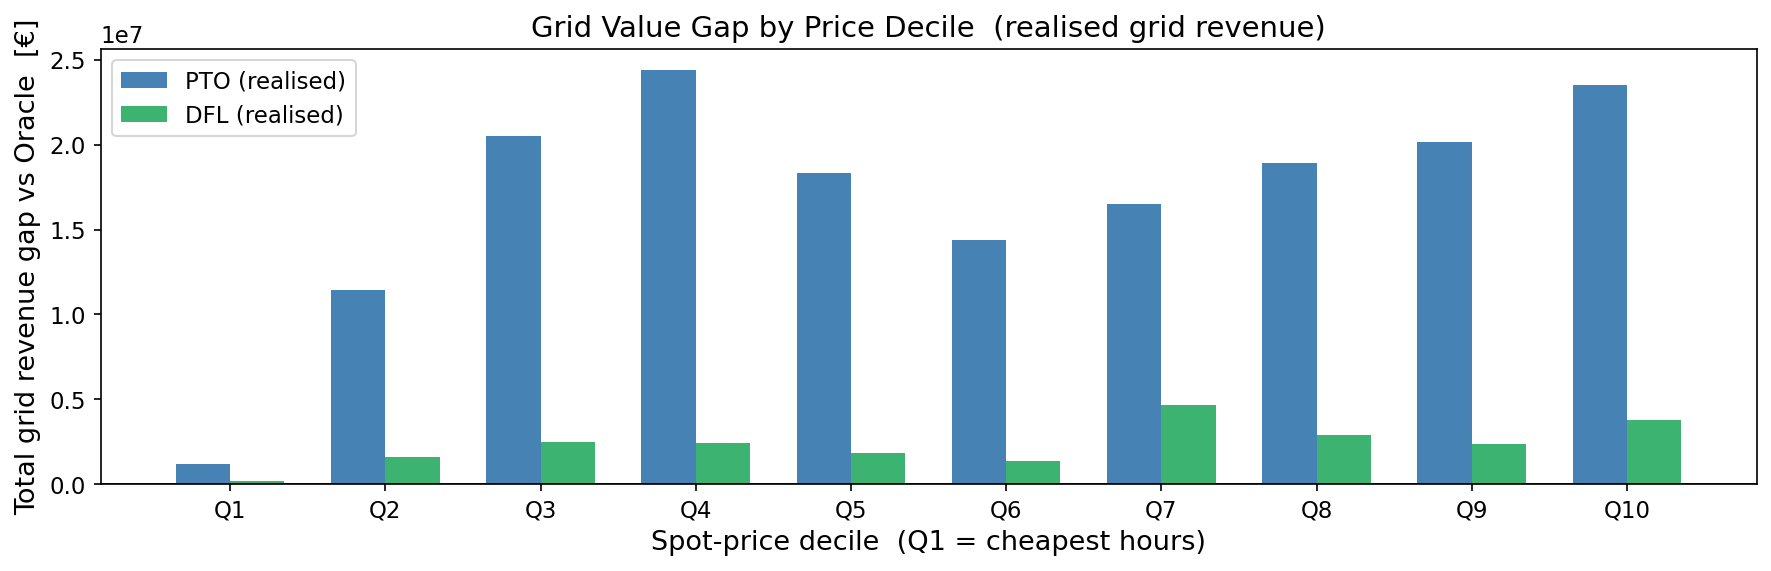


DFL: 38.4% of remaining gap concentrated in top-3 price deciles


In [19]:
label = "Grid Value Gap by Price Decile (Realised)"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")

DELTA_T = 0.25


common = pto.index.intersection(oracle.index)
pto_c  = pto.loc[common]
orc_c  = oracle.loc[common]

orc_grid_t = DELTA_T * orc_c["spot_price"] * orc_c["P_grid"]
pto_grid_t = DELTA_T * pto_c["spot_price"] * pto_c["P_grid_realized"]
pto_gap_t  = (orc_grid_t - pto_grid_t).clip(lower=0)

price_decile = pd.qcut(orc_c["spot_price"], q=10, labels=False)
pto_gap_by_decile = pto_gap_t.groupby(price_decile).sum()

if DFL_AVAILABLE:
    dfl_c = dfl.loc[common.intersection(dfl.index)]
    dfl_grid_t = DELTA_T * dfl_c["spot_price"] * dfl_c["P_grid_realized"]
    dfl_gap_t  = (orc_grid_t - dfl_grid_t).clip(lower=0)
    dfl_gap_by_decile = dfl_gap_t.groupby(price_decile).sum()


print("Average curtailment [MW] (realised):")
print(f"  Oracle : {orc_c['P_curt'].mean():.2f}")
print(f"  PTO    : {pto_c['P_curt_realized'].mean():.2f}")
if DFL_AVAILABLE:
    print(f"  DFL    : {dfl_c['P_curt_realized'].mean():.2f}")

print("\nRealised grid export correlation with Oracle:")
print(f"  PTO : {pto_c['P_grid_realized'].corr(orc_c['P_grid']):.4f}")
if DFL_AVAILABLE:
    print(f"  DFL : {dfl_c['P_grid_realized'].corr(orc_c['P_grid']):.4f}")


x = np.arange(10)
w = 0.35 if DFL_AVAILABLE else 0.5

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - (w/2 if DFL_AVAILABLE else 0), pto_gap_by_decile, w,
       color="steelblue", label="PTO (realised)")
if DFL_AVAILABLE:
    ax.bar(x + w/2, dfl_gap_by_decile, w,
           color="mediumseagreen", label="DFL (realised)")
ax.set_xticks(x)
ax.set_xticklabels([f"Q{i+1}" for i in range(10)])
ax.set_xlabel("Spot-price decile  (Q1 = cheapest hours)")
ax.set_ylabel("Total grid revenue gap vs Oracle  [€]")
ax.set_title("Grid Value Gap by Price Decile  (realised grid revenue)")
ax.axhline(0, color="black", lw=0.8)
ax.legend()
plt.tight_layout()
plt.show()

if DFL_AVAILABLE:
    frac_top3 = dfl_gap_by_decile.iloc[-3:].sum() / dfl_gap_by_decile.sum() * 100
    print(f"\nDFL: {frac_top3:.1f}% of remaining gap concentrated in top-3 price deciles")

### Dispatch Allocation Analysis

In [20]:
label = "3 — Dispatch Allocation Summary"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")


DELTA_T = 0.25

def dispatch_stats(df, label, realized=True):
    """Print energy allocation summary.
    realised=True  - use *_realized columns for PTO/DFL (what actually happened)
    realised=False - use planned columns (Oracle: planned = realised)
    """
    use_r = realized and "P_grid_realized" in df.columns
    total_wind   = DELTA_T * df["P_wind_actual"].sum()
    total_grid   = DELTA_T * (df["P_grid_realized"] if use_r else df["P_grid"]).sum()
    total_ely    = DELTA_T * (df["P_ely_realized"]  if use_r else df["P_ely"]).sum()
    total_bat_ch = DELTA_T * (df["P_ch_realized"]   if use_r else df["P_ch"]).sum()
    total_curt   = DELTA_T * (df["P_curt_realized"] if use_r else df["P_curt"]).sum()
    total_bat_dis = DELTA_T * df["P_dis"].sum()
    total_h2     = (df["H_sell_realized"] if use_r else df["H_sell"]).sum()
    suffix = " (realised)" if use_r else " (planned=realised)"

    print(f"\n{label}{suffix}")
    print("─" * 55)
    print(f"  Total wind generated  : {total_wind:>12,.0f} MWh")
    print(f"  Grid export         : {total_grid:>12,.0f} MWh  ({total_grid/total_wind*100:.1f}%)")
    print(f"  Electrolyser        : {total_ely:>12,.0f} MWh  ({total_ely/total_wind*100:.1f}%)")
    print(f"  Battery (net ch.)   : {total_bat_ch-total_bat_dis:>12,.0f} MWh")
    print(f"  Curtailment         : {total_curt:>12,.0f} MWh  ({total_curt/total_wind*100:.1f}%)")
    print(f"  Battery discharge     : {total_bat_dis:>12,.0f} MWh  (added to supply)")
    print(f"  H₂ sold               : {total_h2:>12,.0f} MWh_H₂")

dispatch_stats(pto,    f"PTO   ({MODEL_NAME})",        realized=True)
dispatch_stats(oracle, "Oracle (perfect foresight)",   realized=False)
if DFL_AVAILABLE:
    dispatch_stats(dfl, f"DFL   ({MODEL_NAME}, SPO+)", realized=True)


  3 — Dispatch Allocation Summary

PTO   (medium_autoreg_lstm_reg_overlap) (realised)
───────────────────────────────────────────────────────
  Total wind generated  :   11,189,907 MWh
  Grid export         :    4,495,167 MWh  (40.2%)
  Electrolyser        :    3,845,868 MWh  (34.4%)
  Battery (net ch.)   :      -17,390 MWh
  Curtailment         :    2,866,263 MWh  (25.6%)
  Battery discharge     :      400,812 MWh  (added to supply)
  H₂ sold               :    2,690,327 MWh_H₂

Oracle (perfect foresight) (planned=realised)
───────────────────────────────────────────────────────
  Total wind generated  :   11,190,856 MWh
  Grid export         :    7,197,751 MWh  (64.3%)
  Electrolyser        :    3,952,548 MWh  (35.3%)
  Battery (net ch.)   :       40,558 MWh
  Curtailment         :            0 MWh  (0.0%)
  Battery discharge     :      375,423 MWh  (added to supply)
  H₂ sold               :    2,687,732 MWh_H₂

DFL   (medium_autoreg_lstm_reg_overlap, SPO+) (realised)
─────────────

  Stacked Dispatch Allocation: Sample Week
  -> Saved stacked_dispatch_allocation-sample_week-3gw_baseline.pdf


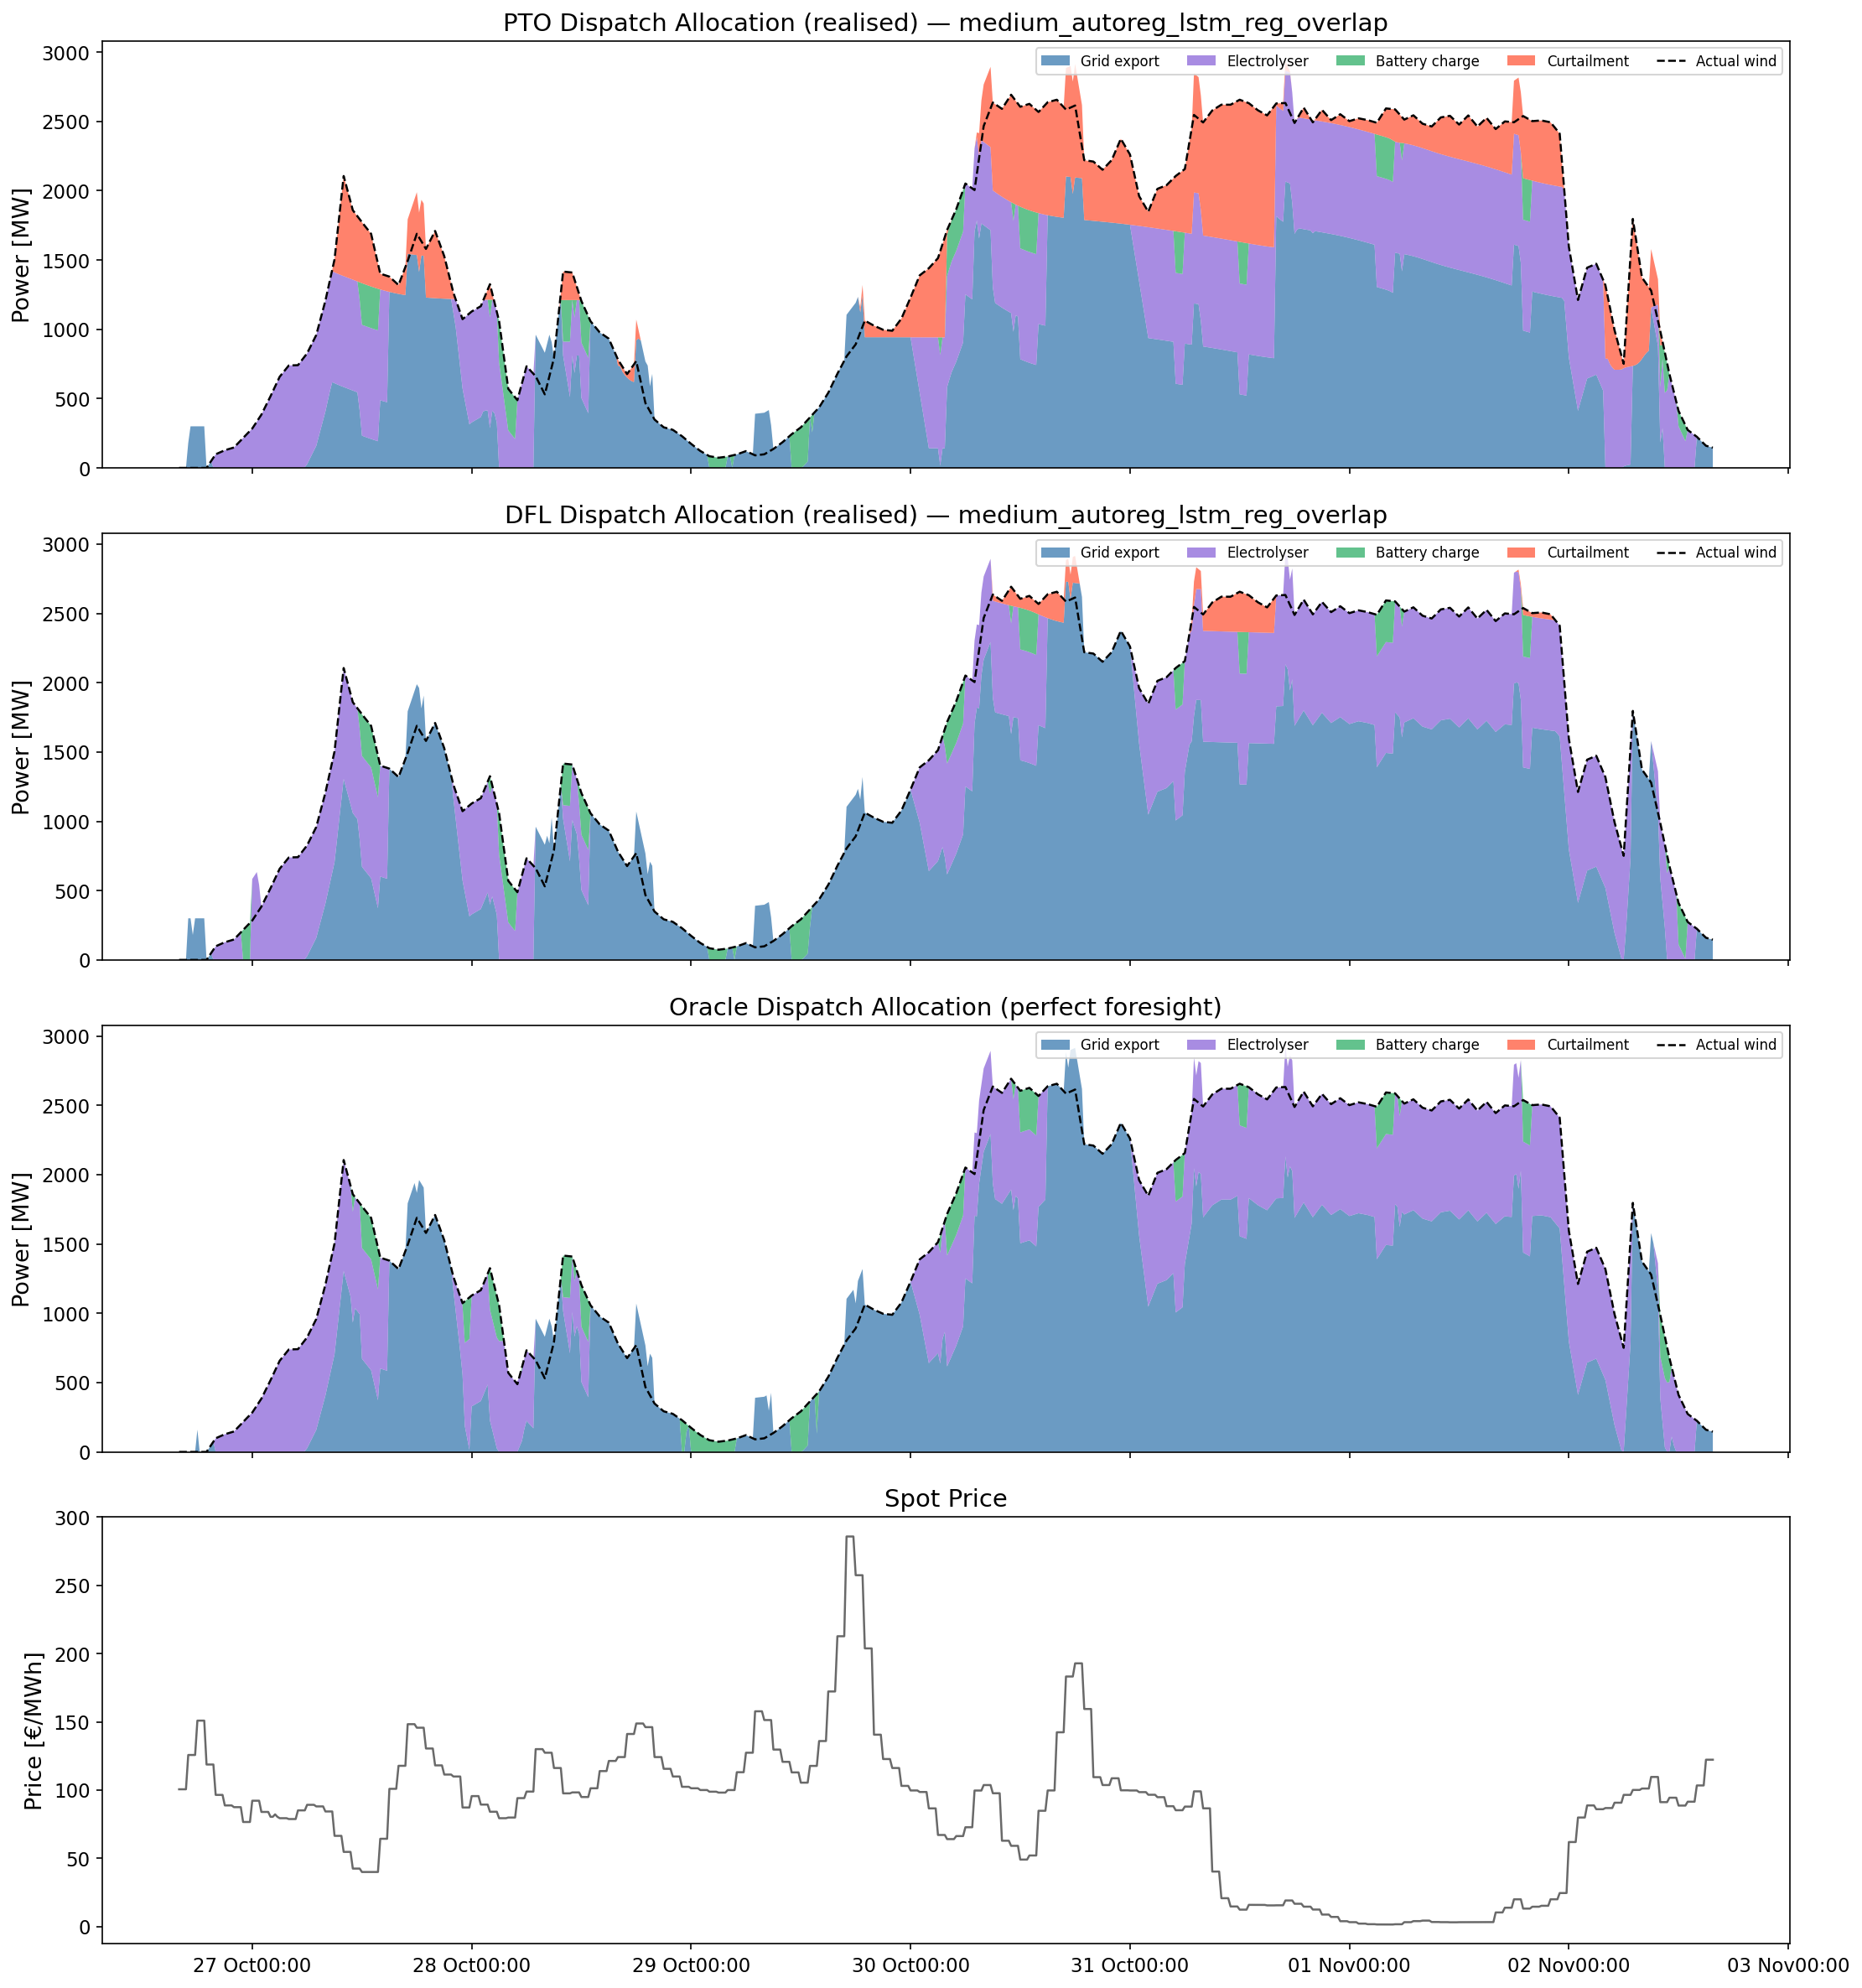

In [21]:
label = "Stacked Dispatch Allocation: Sample Week"
SAMPLE_START_local = SAMPLE_START
SAMPLE_END_local   = SAMPLE_END

print(f"{'='*65}")
print(f"  {label}")
print(f"{'='*65}")


s = pto.iloc[SAMPLE_START_local:SAMPLE_END_local]
common_s = oracle.index.intersection(s.index)
o_s = oracle.loc[common_s]

_dispatch_panels = [(s, f"PTO Dispatch Allocation (realised) — {MODEL_NAME}", True)]
if DFL_AVAILABLE:
    d_s = dfl.iloc[SAMPLE_START_local:SAMPLE_END_local]
    _dispatch_panels.append((d_s, f"DFL Dispatch Allocation (realised) — {MODEL_NAME}", True))
_dispatch_panels.append((o_s, "Oracle Dispatch Allocation (perfect foresight)", False))

n_panels = len(_dispatch_panels) + 1  # +1 for spot price
fig, axes = plt.subplots(n_panels, 1, figsize=(15, 4 * n_panels), sharex=True)

for ax, (df_p, title, use_realized) in zip(axes, _dispatch_panels):
    _pg   = df_p["P_grid_realized"] if (use_realized and "P_grid_realized" in df_p) else df_p["P_grid"]
    _pely = df_p["P_ely_realized"]  if (use_realized and "P_ely_realized"  in df_p) else df_p["P_ely"]
    _pch  = df_p["P_ch_realized"]   if (use_realized and "P_ch_realized"   in df_p) else df_p["P_ch"]
    _pcu  = df_p["P_curt_realized"] if (use_realized and "P_curt_realized" in df_p) else df_p["P_curt"]
    ax.stackplot(
        df_p.index, _pg, _pely, _pch, _pcu,
        labels=["Grid export", "Electrolyser", "Battery charge", "Curtailment"],
        colors=["steelblue", "mediumpurple", "mediumseagreen", "tomato"],
        alpha=0.8,
    )
    ax.plot(df_p.index, df_p["P_wind_actual"], color="black", lw=1.2,
            label="Actual wind", linestyle="--")
    ax.set_ylabel("Power [MW]")
    ax.set_title(title)
    ax.legend(loc="upper right", ncol=5, fontsize=8)

ax = axes[-1]
ax.plot(s.index, s["spot_price"], color="dimgray", lw=1.2)
ax.set_ylabel("Price [€/MWh]")
ax.set_title("Spot Price")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b%H:%M"))

plt.tight_layout()
plt.show()


  Average Dispatch by Hour of Day
  -> Saved average_dispatch_by_hour_of_day-3gw_baseline.pdf


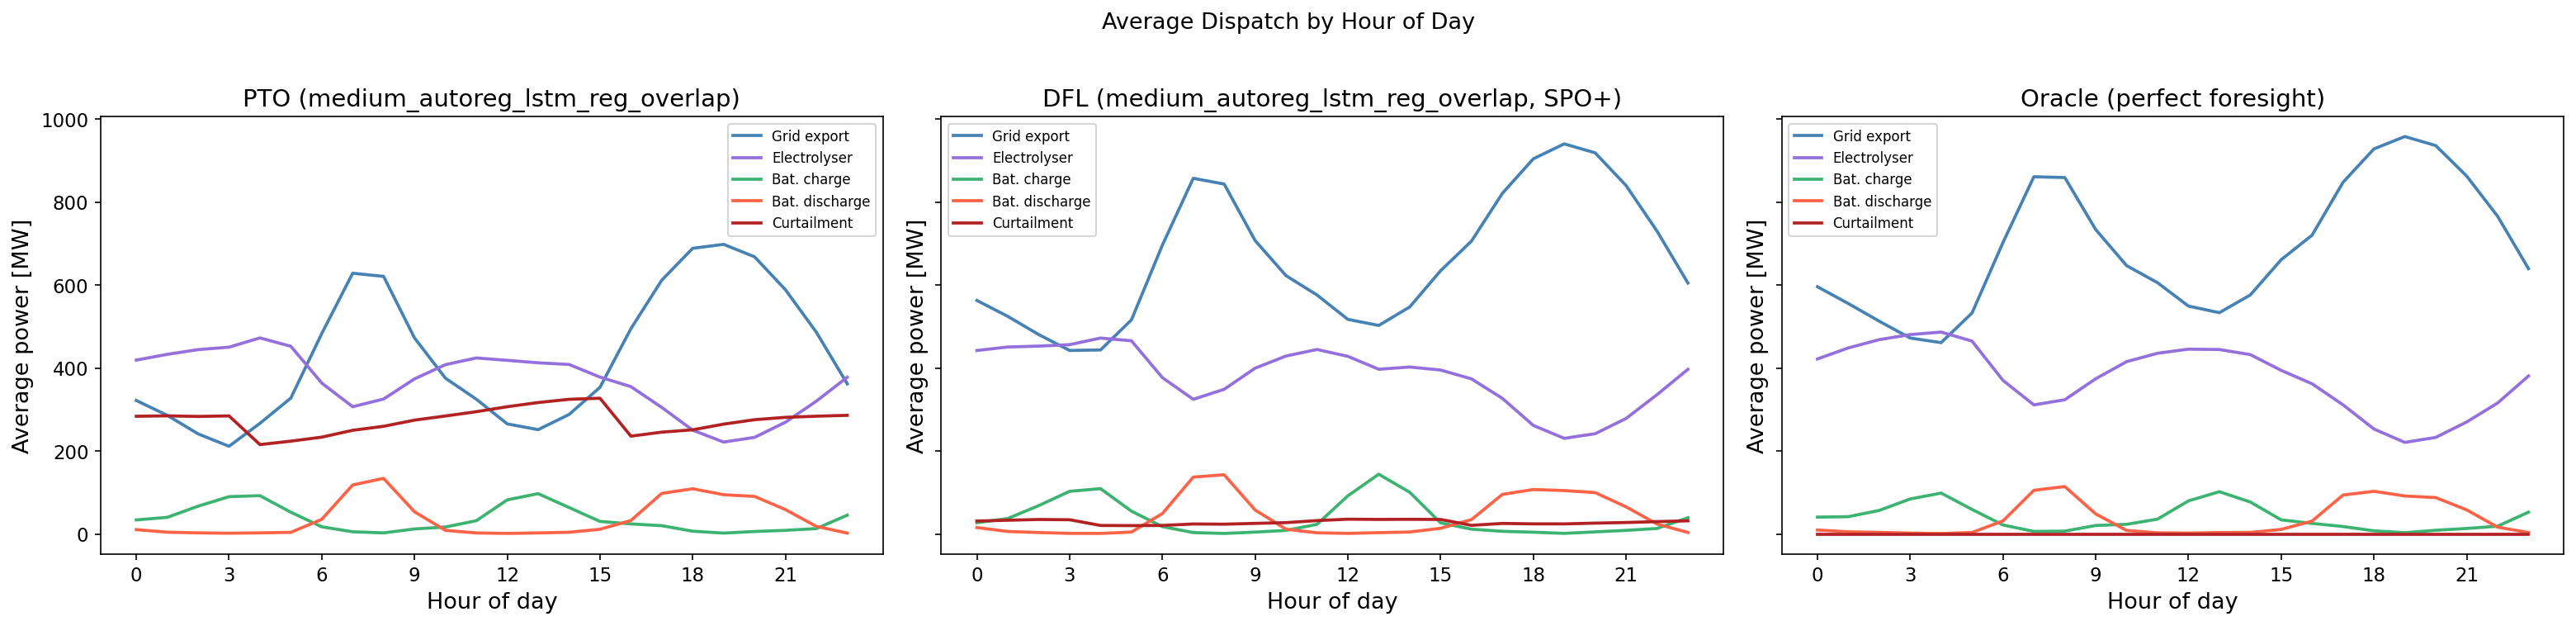

In [22]:
label = "Average Dispatch by Hour of Day"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")


dispatch_cols = ["P_grid", "P_ely", "P_ch", "P_dis", "P_curt"]
colors_map = {"P_grid": "steelblue", "P_ely": "mediumpurple",
              "P_ch": "mediumseagreen", "P_dis": "tomato", "P_curt": "firebrick"}
labels_map = {"P_grid": "Grid export", "P_ely": "Electrolyser",
              "P_ch": "Bat. charge", "P_dis": "Bat. discharge", "P_curt": "Curtailment"}

_realized_map = {
    "P_grid": "P_grid_realized", "P_ely": "P_ely_realized",
    "P_ch":   "P_ch_realized",   "P_curt": "P_curt_realized",
}

def _get_col(df, col, use_realized):
    rc = _realized_map.get(col)
    return df[rc] if (use_realized and rc and rc in df.columns) else df[col]

panels = [(pto, f"PTO ({MODEL_NAME})", True), (oracle, "Oracle (perfect foresight)", False)]
if DFL_AVAILABLE:
    panels.insert(1, (dfl, f"DFL ({MODEL_NAME}, SPO+)", True))

fig, axes = plt.subplots(1, len(panels), figsize=(7 * len(panels), 5), sharey=True)
if len(panels) == 2: axes = list(axes)

for ax, (df, lbl, use_realized) in zip(axes, panels):
    hourly = pd.DataFrame(
        {col: _get_col(df, col, use_realized).groupby(df.index.hour).mean()
         for col in dispatch_cols}
    )
    for col in dispatch_cols:
        ax.plot(hourly.index, hourly[col], label=labels_map[col],
                color=colors_map[col], lw=1.8)
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Average power [MW]")
    ax.set_title(lbl)
    ax.set_xticks(range(0, 24, 3))
    ax.legend(fontsize=8)

plt.suptitle("Average Dispatch by Hour of Day", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


  Dispatch Allocation by Price Decile
  -> Saved dispatch_allocation_by_price_decile-3gw_baseline.pdf


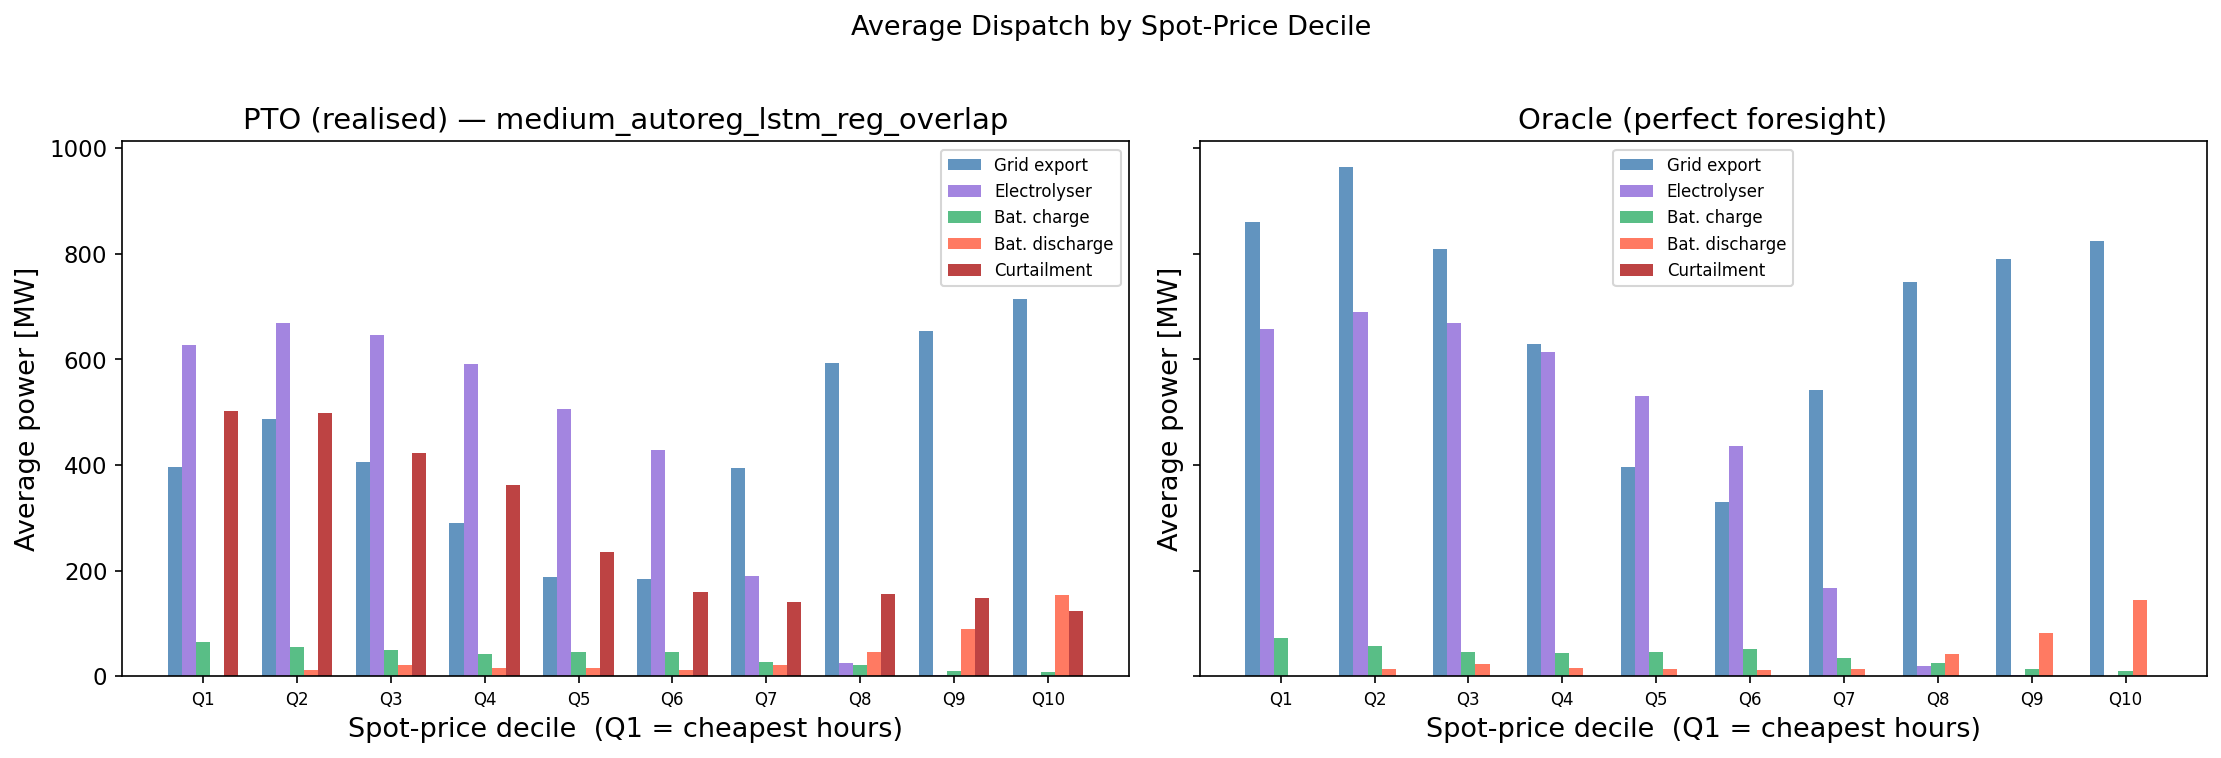


Spot price range per decile:
          min    max
decile              
Q1      -25.4    7.0
Q2        7.0   37.1
Q3       37.2   60.9
Q4       60.9   76.2
Q5       76.2   86.7
Q6       86.7   95.4
Q7       95.4  105.3
Q8      105.3  118.7
Q9      118.8  140.2
Q10     140.2  936.3


In [23]:
label = "Dispatch Allocation by Price Decile"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")


common = pto.index.intersection(oracle.index)
pto_c = pto.loc[common].copy()
orc_c = oracle.loc[common].copy()

price_decile = pd.qcut(orc_c["spot_price"], q=10, labels=[f"Q{i+1}" for i in range(10)])
pto_c["decile"] = price_decile.values
orc_c["decile"] = price_decile.values

dispatch_cols = ["P_grid", "P_ely", "P_ch", "P_dis", "P_curt"]
_real_map = {
    "P_grid": "P_grid_realized", "P_ely": "P_ely_realized",
    "P_ch":   "P_ch_realized",   "P_curt": "P_curt_realized",
}

pto_real = pto_c[["decile"]].copy()
for col in dispatch_cols:
    pto_real[col] = pto_c[_real_map[col]] if _real_map.get(col) in pto_c.columns else pto_c[col]

pto_by_price  = pto_real.groupby("decile")[dispatch_cols].mean()
orc_by_price  = orc_c.groupby("decile")[dispatch_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
colors_d = ["steelblue", "mediumpurple", "mediumseagreen", "tomato", "firebrick"]
labels_d = ["Grid export", "Electrolyser", "Bat. charge", "Bat. discharge", "Curtailment"]

for ax, (data, title) in zip(axes, [
    (pto_by_price, f"PTO (realised) — {MODEL_NAME}"),
    (orc_by_price, "Oracle (perfect foresight)"),
]):
    x = np.arange(len(data))
    w = 0.15
    for i, (col, lbl, clr) in enumerate(zip(dispatch_cols, labels_d, colors_d)):
        ax.bar(x + i * w, data[col], w, label=lbl, color=clr, alpha=0.85)
    ax.set_xticks(x + w * 2)
    ax.set_xticklabels(data.index, fontsize=8)
    ax.set_xlabel("Spot-price decile  (Q1 = cheapest hours)")
    ax.set_ylabel("Average power [MW]")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("Average Dispatch by Spot-Price Decile", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


price_ranges = orc_c.groupby("decile")["spot_price"].agg(["min", "max"]).round(1)
print("\nSpot price range per decile:")
print(price_ranges.to_string())

## Export Deficit Events & Imbalance Market Bias

In [24]:
label = "Export Deficit Event Summary"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")


n_ts_pto = pto_summary["n_timesteps"]

print("Export Deficis Summary (test split)")
print("=" * 55)
print(f"\nOracle:")
print(f"  Export Deficit Events   : 0  (perfect foresight — no deficit possible)")

print(f"\nPTO ({MODEL_NAME}):")
n_viol_pto = pto_summary.get("n_violations", 0)
print(f"  Export Deficit Events : {n_viol_pto:,}  /  {n_ts_pto:,} timesteps  ({n_viol_pto/n_ts_pto*100:.2f}%)")
print(f"  Worst deficit     : {pto_summary.get('worst_deficit_mw', 0):.1f} MW")
print(f"  Planned profit    : €{pto_summary['objective_value']:>18,.2f}")
print(f"  Realised profit   : €{pto_summary.get('realized_profit', float('nan')):>18,.2f}")

if DFL_AVAILABLE:
    n_ts_dfl = dfl_summary["n_timesteps"]
    n_viol_dfl = dfl_summary.get("n_violations", 0)
    print(f"\nDFL ({MODEL_NAME}, SPO+):")
    print(f"  Export Deficit Events : {n_viol_dfl:,}  /  {n_ts_dfl:,} timesteps  ({n_viol_dfl/n_ts_dfl*100:.2f}%)")
    print(f"  Worst deficit     : {dfl_summary.get('worst_deficit_mw', 0):.1f} MW")
    print(f"  Planned profit    : €{dfl_summary['objective_value']:>18,.2f}")
    print(f"  Realised profit   : €{dfl_summary.get('realized_profit', float('nan')):>18,.2f}")




  Export Deficit Event Summary
Export Deficis Summary (test split)

Oracle:
  Export Deficit Events   : 0  (perfect foresight — no deficit possible)

PTO (medium_autoreg_lstm_reg_overlap):
  Export Deficit Events : 10,499  /  41,760 timesteps  (25.14%)
  Worst deficit     : 1100.0 MW
  Planned profit    : €  1,167,090,699.25
  Realised profit   : €    524,044,976.76

DFL (medium_autoreg_lstm_reg_overlap, SPO+):
  Export Deficit Events : 11,697  /  41,760 timesteps  (28.01%)
  Worst deficit     : 1100.0 MW
  Planned profit    : €  2,236,741,331.66
  Realised profit   : €    948,328,226.77


In [25]:
label = "Per-Timestep Export Deficit Event Detection"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")



SHED_THRESHOLD = 0.01  

pto["deficit_mw"]    = (pto["P_grid"] - pto["P_grid_realized"]).clip(lower=0) if "P_grid_realized" in pto.columns else (pto["P_ely"] - pto["P_ely_realized"]).clip(lower=0)
pto["is_violation"]  = pto["deficit_mw"] > SHED_THRESHOLD

if DFL_AVAILABLE:
    dfl["deficit_mw"]   = (dfl["P_grid"] - dfl["P_grid_realized"]).clip(lower=0) if "P_grid_realized" in dfl.columns else (dfl["P_ely"] - dfl["P_ely_realized"]).clip(lower=0)
    dfl["is_violation"] = dfl["deficit_mw"] > SHED_THRESHOLD

print(f"PTO export deficit events detected per-timestep : {pto['is_violation'].sum():,}")
print(f"PTO avg deficit when export fails       : {pto.loc[pto['is_violation'], 'deficit_mw'].mean():.1f} MW")
print(f"PTO max deficit                      : {pto['deficit_mw'].max():.1f} MW")
if DFL_AVAILABLE:
    print(f"\nDFL export deficit events detected per-timestep : {dfl['is_violation'].sum():,}")
    print(f"DFL avg deficit when export fails       : {dfl.loc[dfl['is_violation'], 'deficit_mw'].mean():.1f} MW")
    print(f"DFL max deficit                      : {dfl['deficit_mw'].max():.1f} MW")


  Per-Timestep Export Deficit Event Detection
PTO export deficit events detected per-timestep : 17,929
PTO avg deficit when export fails       : 503.5 MW
PTO max deficit                      : 2118.8 MW

DFL export deficit events detected per-timestep : 36,886
DFL avg deficit when export fails       : 1222.2 MW
DFL max deficit                      : 2924.3 MW


### Cross-Scenario Comparison 



In [26]:

ALL_SCENARIOS = [
    ("3gw",    "baseline",            "3GW — Baseline\n(€150/MWh H₂)"),
    ("3gw",    "low_h2_price",        "3GW — Low H₂\n(€100/MWh)"),
    ("3gw",    "high_h2_price",       "3GW — High H₂\n(€200/MWh)"),
    ("3800mw", "baseline_3800mw",     "3800MW — Baseline\n(€150/MWh H₂)"),
    ("3800mw", "low_h2_price_3800mw", "3800MW — Low H₂\n(€100/MWh)"),
    ("3800mw", "high_h2_price_3800mw","3800MW — High H₂\n(€200/MWh)"),
]

def load_summary(path):
    try:
        with open(path / "summary.json") as f:
            return json.load(f)
    except FileNotFoundError:
        return None

rows = []
for wf, scen, label in ALL_SCENARIOS:
    suffix = f"_{scen}"
    oracle_d = ORACLE_RESULTS_DIR / f"oracle_{wf}_test{suffix}"
    pto_d    = ML_RESULTS_DIR     / f"pto_{wf}_test_{MODEL_NAME}{suffix}"
    dfl_d    = ML_RESULTS_DIR     / f"dfl_{wf}_{MODEL_NAME}{suffix}"

    o = load_summary(oracle_d)
    p = load_summary(pto_d)
    d = load_summary(dfl_d)

    oracle_profit = o["objective_value"]       if o else float("nan") 
    pto_profit    = p.get("realized_profit")   if p else float("nan")
    dfl_profit    = d.get("realized_profit")   if d else float("nan")
    pto_viol      = p.get("n_violations", 0)   if p else float("nan")
    dfl_viol      = d.get("n_violations", 0)   if d else float("nan")

    rows.append({
        "Scenario":           label,
        "Oracle (€M)":        oracle_profit / 1e6,
        "PTO (€M)":           pto_profit    / 1e6,
        "DFL (€M)":           dfl_profit    / 1e6,
        "PTO gap (%)":        (oracle_profit - pto_profit) / oracle_profit * 100 if pto_profit else float("nan"),
        "DFL gap (%)":        (oracle_profit - dfl_profit) / oracle_profit * 100 if dfl_profit else float("nan"),
        "PTO export deficit events":     pto_viol,
        "DFL export deficit events":     dfl_viol,
    })

df_all = pd.DataFrame(rows).set_index("Scenario")


pd.set_option("display.float_format", "{:.2f}".format)
print("Realised Profit & Optimality Gap — All Scenarios\n")
print(df_all[["Oracle (€M)", "PTO (€M)", "DFL (€M)", "PTO gap (%)", "DFL gap (%)"]].to_string())
print()
print("Export Deficits\n")
print(df_all[["PTO export deficit events", "DFL export deficit events"]].to_string())

Realised Profit & Optimality Gap — All Scenarios

                                  Oracle (€M)  PTO (€M)  DFL (€M)  PTO gap (%)  DFL gap (%)
Scenario                                                                                   
3GW — Baseline\n(€150/MWh H₂)          971.39    524.04    948.33        46.05         2.37
3GW — Low H₂\n(€100/MWh)               868.50    417.81    836.86        51.89         3.64
3GW — High H₂\n(€200/MWh)             1129.58    680.39   1112.61        39.77         1.50
3800MW — Baseline\n(€150/MWh H₂)      1179.11    551.15   1131.93        53.26         4.00
3800MW — Low H₂\n(€100/MWh)           1072.24    440.55    994.74        58.91         7.23
3800MW — High H₂\n(€200/MWh)          1346.09    714.82   1292.33        46.90         3.99

Export Deficits

                                  PTO export deficit events  DFL export deficit events
Scenario                                                                              
3GW — Baseline\n(€150/

In [27]:

def load_scenario_data(wf, scen):
    """Load PTO, DFL (if available) and Oracle dispatches for one scenario."""
    suffix = f"_{scen}"
    pto_d    = ML_RESULTS_DIR     / f"pto_{wf}_test_{MODEL_NAME}{suffix}"
    dfl_d    = ML_RESULTS_DIR     / f"dfl_{wf}_{MODEL_NAME}{suffix}"
    oracle_d = ORACLE_RESULTS_DIR / f"oracle_{wf}_test{suffix}"

    pto_s    = pd.read_parquet(pto_d    / "dispatch_pto.parquet")
    oracle_s = pd.read_parquet(oracle_d / "dispatch_oracle.parquet")
    with open(pto_d    / "summary.json") as f: pto_sum    = json.load(f)
    with open(oracle_d / "summary.json") as f: oracle_sum = json.load(f)

    dfl_s = dfl_sum = None
    try:
        dfl_s = pd.read_parquet(dfl_d / "dispatch_dfl.parquet")
        with open(dfl_d / "summary.json") as f: dfl_sum = json.load(f)
    except FileNotFoundError:
        pass

    return pto_s, dfl_s, oracle_s, pto_sum, dfl_sum, oracle_sum


  -> Saved 3800mw_high_h₂_200-mwh-3gw_baseline.pdf


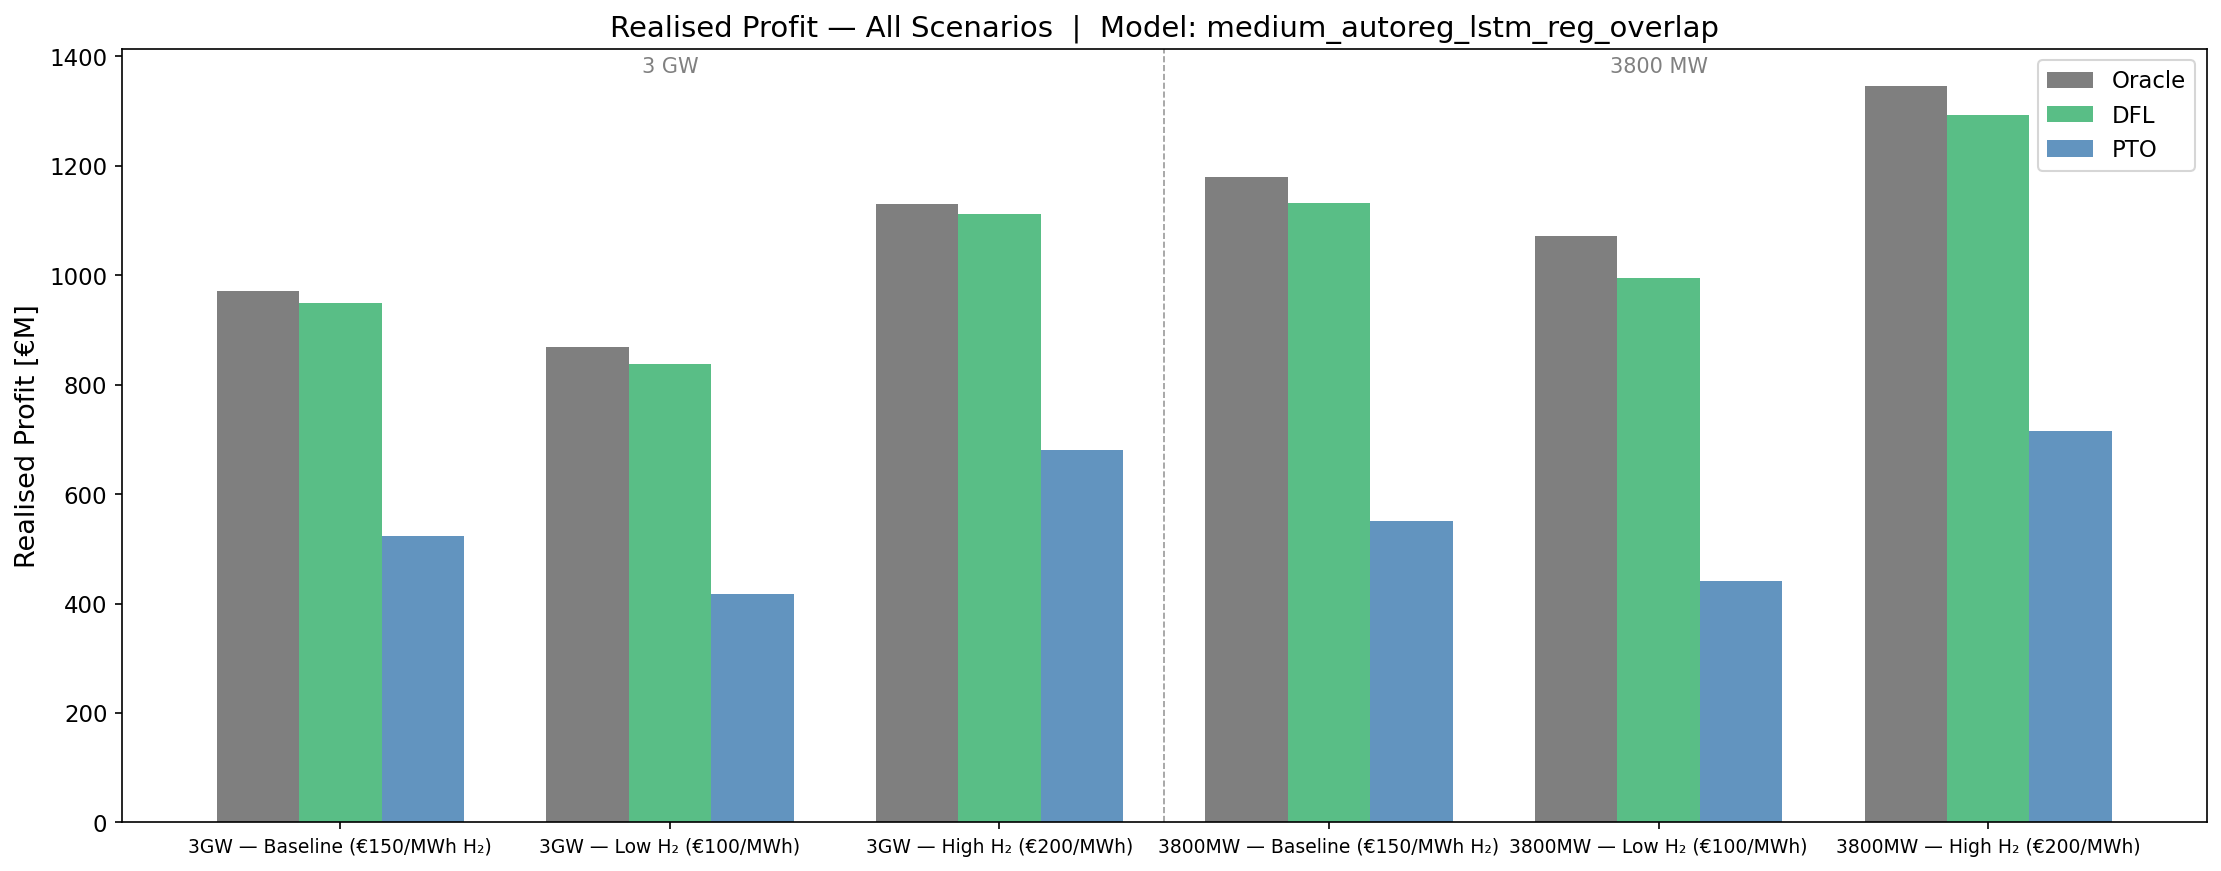

In [28]:
#  Realised profit bar chart 
labels  = [s.replace("\n", " ") for s in df_all.index]
x       = np.arange(len(labels))
w       = 0.25

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - w,   df_all["Oracle (€M)"], w, label="Oracle",   color="dimgray",       alpha=0.85)
ax.bar(x,       df_all["DFL (€M)"],    w, label="DFL",      color="mediumseagreen", alpha=0.85)
ax.bar(x + w,   df_all["PTO (€M)"],    w, label="PTO",      color="steelblue",      alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Realised Profit [€M]")
ax.set_title(f"Realised Profit — All Scenarios  |  Model: {MODEL_NAME}")
ax.legend()
ax.axvline(2.5, color="black", lw=0.8, linestyle="--", alpha=0.4)   # separator 3GW | 3800MW
ax.text(1,   ax.get_ylim()[1]*0.97, "3 GW",    ha="center", fontsize=10, color="gray")
ax.text(4,   ax.get_ylim()[1]*0.97, "3800 MW", ha="center", fontsize=10, color="gray")
plt.tight_layout()
plt.show()

  -> Saved 3800mw_high_h₂_200-mwh-3gw_baseline.pdf


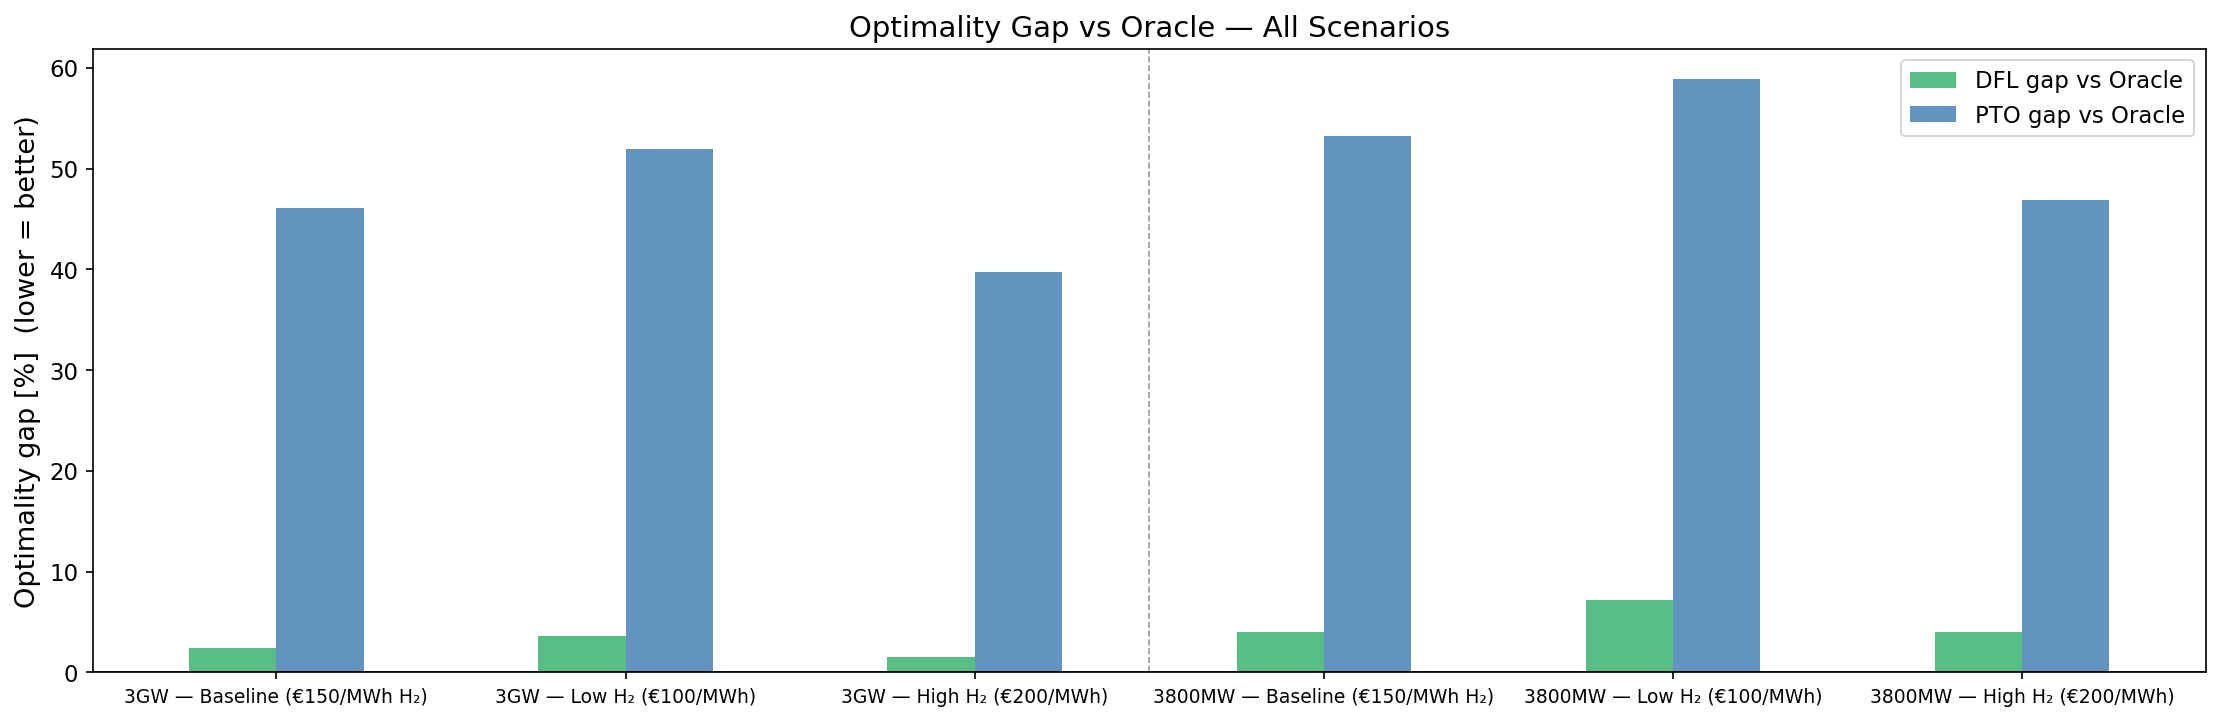

In [29]:
# Optimality gap (%)
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - w/2, df_all["DFL gap (%)"], w, label="DFL gap vs Oracle", color="mediumseagreen", alpha=0.85)
ax.bar(x + w/2, df_all["PTO gap (%)"], w, label="PTO gap vs Oracle", color="steelblue",      alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Optimality gap [%]  (lower = better)")
ax.set_title("Optimality Gap vs Oracle — All Scenarios")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(2.5, color="black", lw=0.8, linestyle="--", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

  -> Saved 3800mw_high_h₂_200-mwh-3gw_baseline.pdf


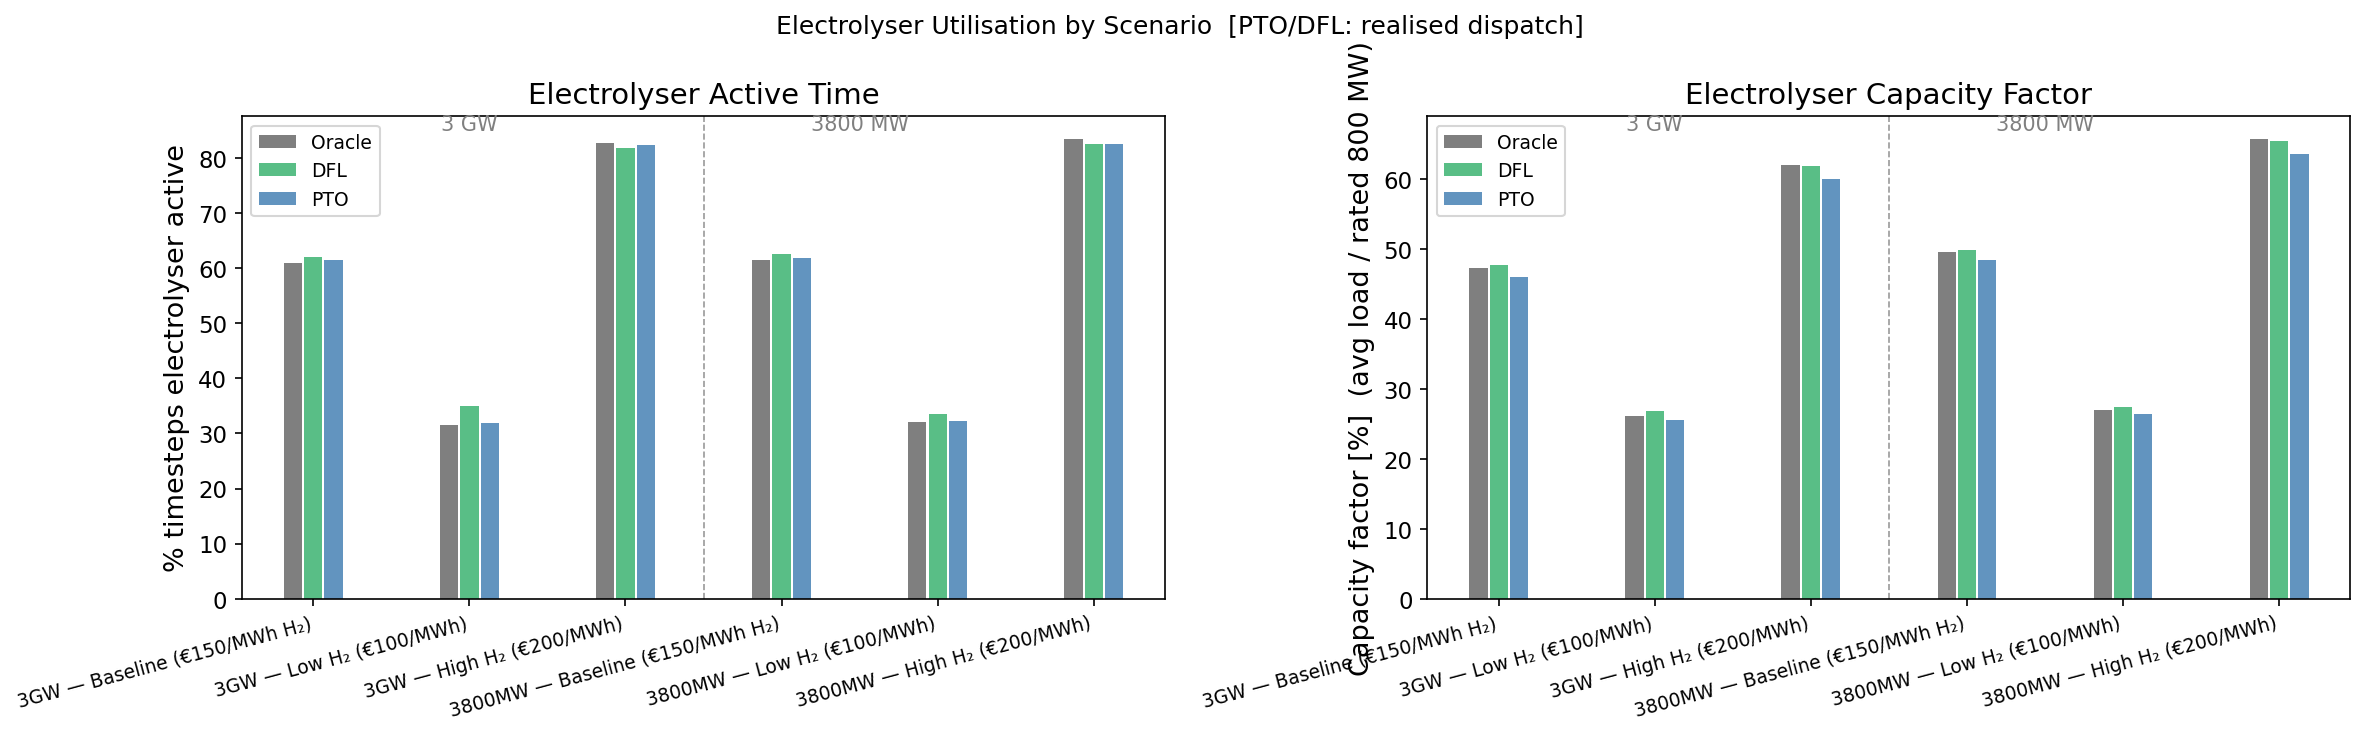


Electrolyser utilisation and capacity factor (PTO/DFL = realised):
                                 Oracle active [%]  Oracle CF [%]  PTO active [%]  PTO CF [%]  DFL active [%]  DFL CF [%]
Scenario                                                                                                                 
3GW — Baseline (€150/MWh H₂)                 60.90          47.30           61.40       46.00           62.10       47.70
3GW — Low H₂ (€100/MWh)                      31.60          26.20           31.90       25.50           34.90       26.90
3GW — High H₂ (€200/MWh)                     82.80          62.00           82.30       60.00           81.80       61.90
3800MW — Baseline (€150/MWh H₂)              61.50          49.60           61.80       48.40           62.50       49.90
3800MW — Low H₂ (€100/MWh)                   32.10          27.00           32.30       26.40           33.60       27.40
3800MW — High H₂ (€200/MWh)                  83.40          65.70           82

In [30]:
#  Electrolyser utilisation rate and capacity factor by scenario

from scenarios import find_scenario as _fs_ely

ely_rows = []
for wf, scen, label in ALL_SCENARIOS:
    pto_s, dfl_s, oracle_s, pto_sum, dfl_sum, oracle_sum = load_scenario_data(wf, scen)
    _sc_cfg   = _fs_ely(scen) if scen else {}
    _p_ely_max = _sc_cfg.get("P_ELY_MAX", 800)
    lbl = label.replace("\n", " ")

    _oracle_active = (oracle_s["P_ely"]          > 1).mean() * 100
    _pto_active    = (pto_s["P_ely_realized"]     > 1).mean() * 100
    _dfl_active    = (dfl_s["P_ely_realized"]     > 1).mean() * 100 if dfl_s is not None else float("nan")

    _oracle_cf = oracle_s["P_ely"].mean()          / _p_ely_max * 100
    _pto_cf    = pto_s["P_ely_realized"].mean()    / _p_ely_max * 100
    _dfl_cf    = dfl_s["P_ely_realized"].mean()    / _p_ely_max * 100 if dfl_s is not None else float("nan")

    ely_rows.append({
        "Scenario":          lbl,
        "Oracle active [%]": round(_oracle_active, 1),
        "Oracle CF [%]":     round(_oracle_cf,     1),
        "PTO active [%]":    round(_pto_active,    1),
        "PTO CF [%]":        round(_pto_cf,        1),
        "DFL active [%]":    round(_dfl_active,    1),
        "DFL CF [%]":        round(_dfl_cf,        1),
    })

df_ely = pd.DataFrame(ely_rows).set_index("Scenario")


x = np.arange(len(df_ely)); w = 0.13
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

for ax, (active_col, cf_col, method, clr) in zip(
    [axes[0], axes[0], axes[0]],
    [("Oracle active [%]", "Oracle CF [%]", "Oracle",  "dimgray"),
     ("DFL active [%]",    "DFL CF [%]",    "DFL",     "mediumseagreen"),
     ("PTO active [%]",    "PTO CF [%]",    "PTO",     "steelblue")],
):
    pass  

offsets = [-1, 0, 1]
method_styles = [
    ("Oracle active [%]", "Oracle CF [%]", "Oracle", "dimgray"),
    ("DFL active [%]",    "DFL CF [%]",    "DFL",    "mediumseagreen"),
    ("PTO active [%]",    "PTO CF [%]",    "PTO",    "steelblue"),
]

for ax_idx, metric_key, ylabel in [
    (0, "active", "% timesteps electrolyser active"),
    (1, "cf",     "Capacity factor [%]  (avg load / rated 800 MW)"),
]:
    ax = axes[ax_idx]
    for i, (active_col, cf_col, method, clr) in enumerate(method_styles):
        col = active_col if metric_key == "active" else cf_col
        ax.bar(x + offsets[i] * w, df_ely[col], w * 0.9, label=method, color=clr, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(df_ely.index, fontsize=9, rotation=15, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title("Electrolyser Active Time" if metric_key == "active" else "Electrolyser Capacity Factor")
    ax.axvline(2.5, color="black", lw=0.8, linestyle="--", alpha=0.4)
    ax.text(1,   ax.get_ylim()[1]*0.97, "3 GW",    ha="center", color="gray", fontsize=10)
    ax.text(3.5, ax.get_ylim()[1]*0.97, "3800 MW", ha="center", color="gray", fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle("Electrolyser Utilisation by Scenario  [PTO/DFL: realised dispatch]", fontsize=12)
plt.tight_layout()
plt.show()

print("\nElectrolyser utilisation and capacity factor (PTO/DFL = realised):")
print(df_ely.round(1).to_string())

  -> Saved 3800mw_high_h₂_200-mwh-3gw_baseline.pdf


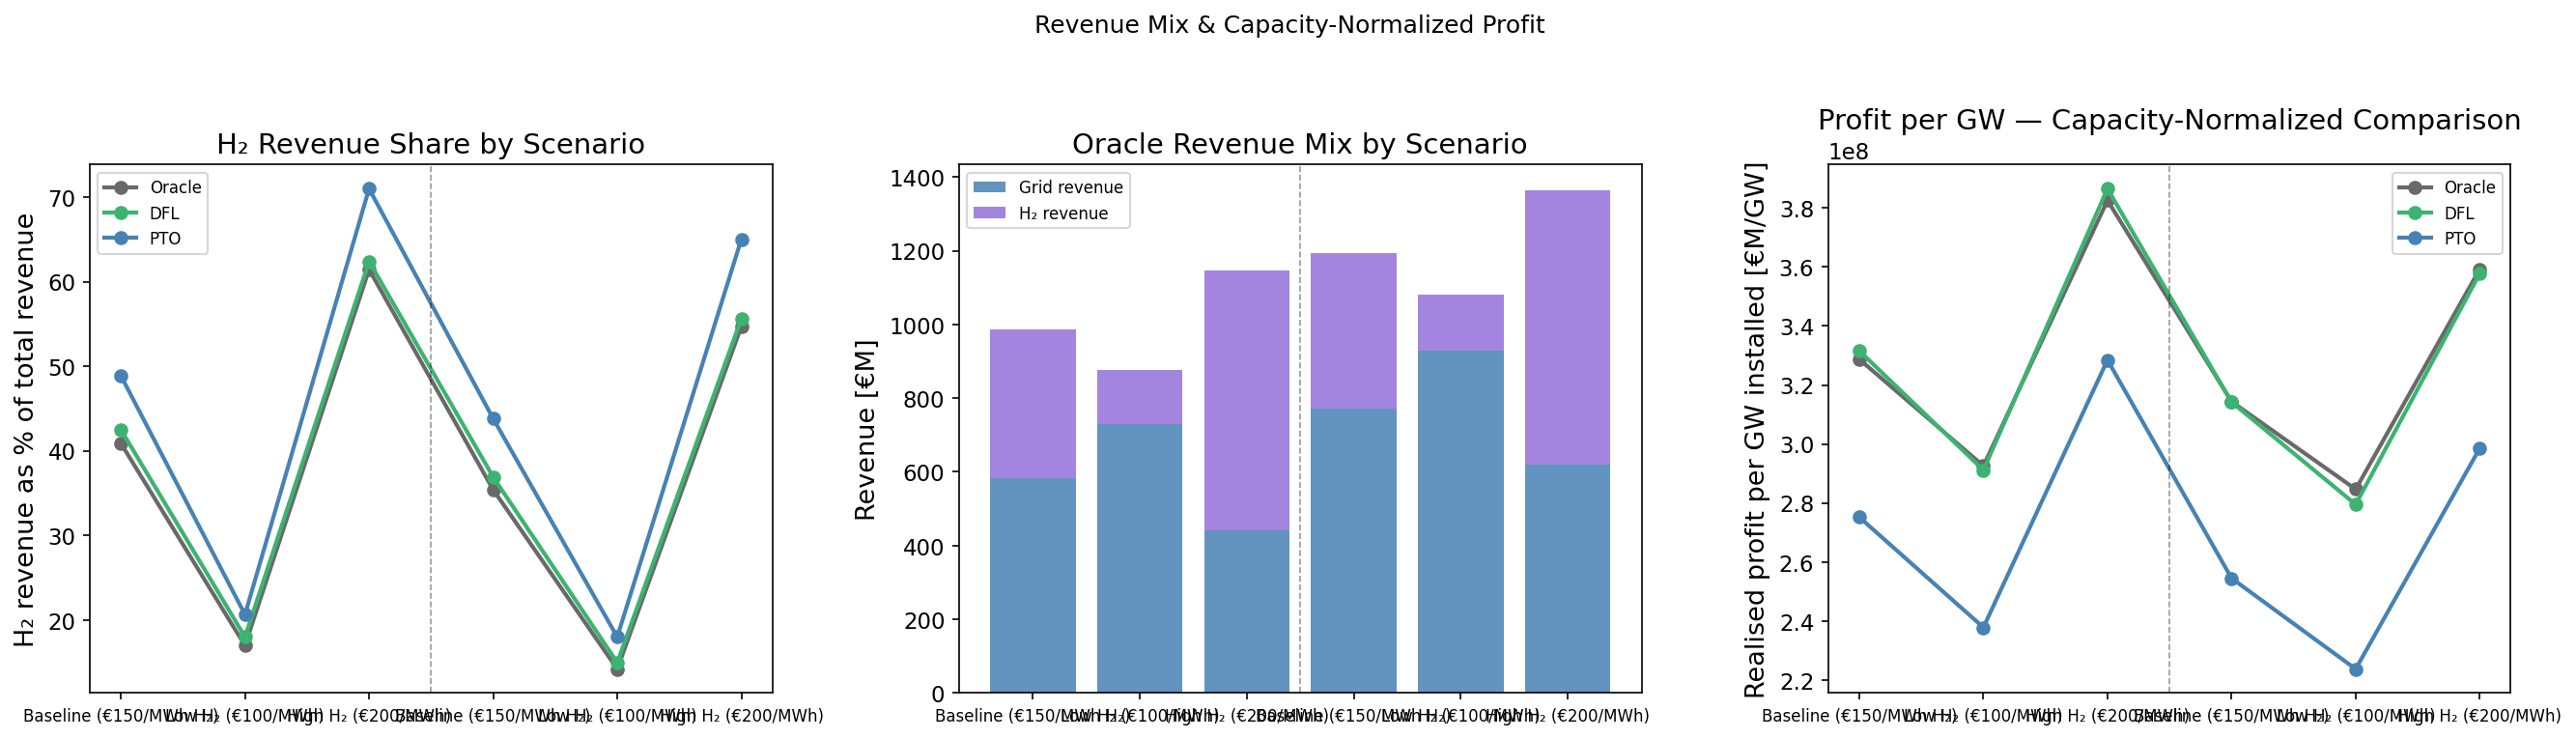

In [31]:
from optimization import pi_H2 as _pi_H2_def_mix
from scenarios  import find_scenario as _fs_mix
DELTA_T = 0.25

#  Revenue source mix + per-MW normalized profit by scenario
mix_rows = []
for wf, scen, label in ALL_SCENARIOS:
    pto_s, dfl_s, oracle_s, pto_sum, dfl_sum, oracle_sum = load_scenario_data(wf, scen)
    cap = {"3gw": 3000, "3800mw": 3800}[wf]
    lbl = label.replace("\n", " ")
    _sc_mix    = _fs_mix(scen) if scen else {}
    _pi_H2_mix = _sc_mix.get("pi_H2", _pi_H2_def_mix)
    for df_m, method, realized in [
        (oracle_s, "Oracle", False),
        (pto_s,    "PTO",    True),
        *( [(dfl_s, "DFL", True)] if dfl_s is not None else [] ),
    ]:
        pg = df_m["P_grid_realized"] if (realized and "P_grid_realized" in df_m) else df_m["P_grid"]
        hs = df_m["H_sell_realized"] if (realized and "H_sell_realized" in df_m) else df_m["H_sell"]
        grid_r = DELTA_T * (df_m["spot_price"] * pg).sum()
        h2_r   = _pi_H2_mix * hs.sum()          # H_sell in MWh_H2 — no DELTA_T
        total  = grid_r + h2_r
        mix_rows.append({
            "Scenario": lbl, "Method": method, "Capacity MW": cap,
            "Grid €M":   grid_r / 1e6,
            "H₂ €M":     h2_r   / 1e6,
            "Total €M":  total  / 1e6,
            "H₂ share %": h2_r / total * 100 if total > 0 else 0,
            "€M per GW":  total / (cap / 1000),
        })

df_mix = pd.DataFrame(mix_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


ax = axes[0]
for method, color in [("Oracle","dimgray"),("DFL","mediumseagreen"),("PTO","steelblue")]:
    sub = df_mix[df_mix["Method"] == method]
    ax.plot(range(len(sub)), sub["H₂ share %"].values, marker="o", label=method, color=color, lw=2)
ax.set_xticks(range(6))
ax.set_xticklabels([r.replace("3GW — ","").replace("3800MW — ","") 
                    for r in df_mix[df_mix["Method"]=="Oracle"]["Scenario"]], fontsize=8)
ax.set_ylabel("H₂ revenue as % of total revenue")
ax.set_title("H₂ Revenue Share by Scenario")
ax.legend(fontsize=8); ax.axvline(2.5, color="black", lw=0.8, linestyle="--", alpha=0.4)
ax.grid(False)

ax = axes[1]
orc_mix = df_mix[df_mix["Method"] == "Oracle"]
ax.bar(range(6), orc_mix["Grid €M"], color="steelblue",    alpha=0.85, label="Grid revenue")
ax.bar(range(6), orc_mix["H₂ €M"],  bottom=orc_mix["Grid €M"].values,
       color="mediumpurple", alpha=0.85, label="H₂ revenue")
ax.set_xticks(range(6))
ax.set_xticklabels(orc_mix["Scenario"].str.replace("3GW — ","").str.replace("3800MW — ",""), fontsize=8)
ax.set_ylabel("Revenue [€M]")
ax.set_title("Oracle Revenue Mix by Scenario")
ax.legend(fontsize=8); ax.axvline(2.5, color="black", lw=0.8, linestyle="--", alpha=0.4)
ax.grid(False)


ax = axes[2]
for method, color in [("Oracle","dimgray"),("DFL","mediumseagreen"),("PTO","steelblue")]:
    sub = df_mix[df_mix["Method"] == method]
    ax.plot(range(len(sub)), sub["€M per GW"].values, marker="o", label=method, color=color, lw=2)
ax.set_xticks(range(6))
ax.set_xticklabels([r.replace("3GW — ","").replace("3800MW — ","")
                    for r in df_mix[df_mix["Method"]=="Oracle"]["Scenario"]], fontsize=8)
ax.set_ylabel("Realised profit per GW installed [€M/GW]")
ax.set_title("Profit per GW — Capacity-Normalized Comparison")
ax.legend(fontsize=8); ax.axvline(2.5, color="black", lw=0.8, linestyle="--", alpha=0.4)
ax.grid(False)

plt.suptitle("Revenue Mix & Capacity-Normalized Profit", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


  -> Saved 3800mw_high_h₂_200-mwh-3gw_baseline.pdf


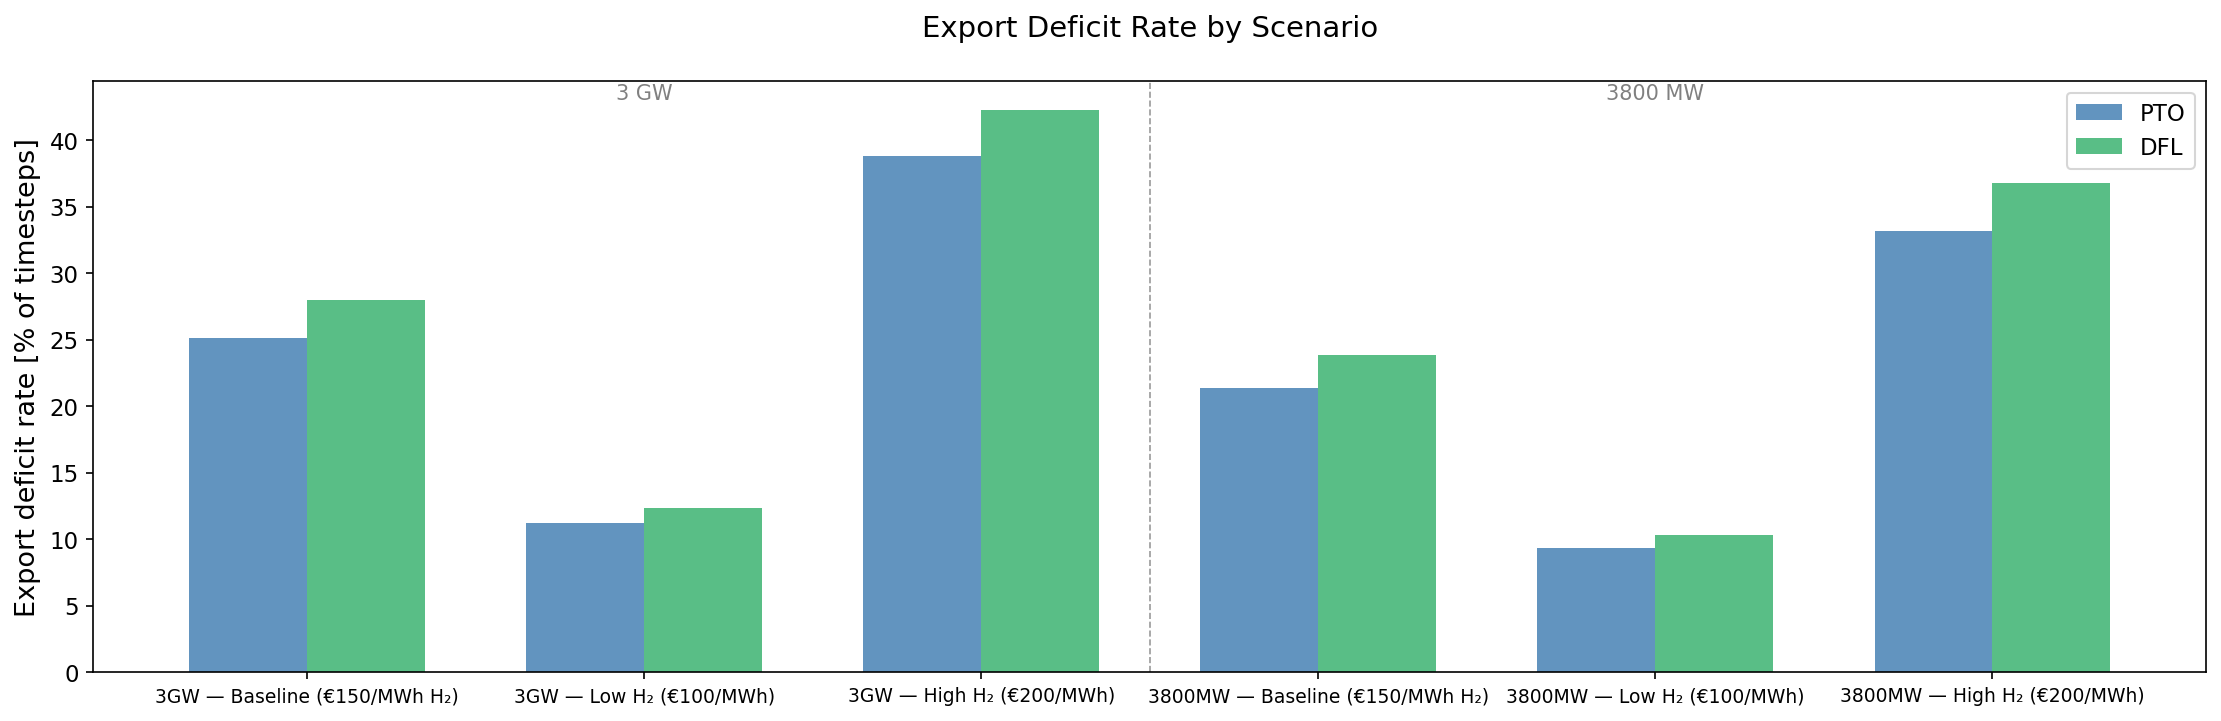


Export deficit rates (%):
                                 PTO viol. rate  DFL viol. rate
Scenario                                                       
3GW — Baseline (€150/MWh H₂)              25.14           28.01
3GW — Low H₂ (€100/MWh)                   11.25           12.37
3GW — High H₂ (€200/MWh)                  38.80           42.30
3800MW — Baseline (€150/MWh H₂)           21.35           23.83
3800MW — Low H₂ (€100/MWh)                 9.38           10.31
3800MW — High H₂ (€200/MWh)               33.14           36.77


In [32]:

viol_rows = []
for wf, scen, label in ALL_SCENARIOS:
    _, dfl_s, _, pto_sum, dfl_sum, _ = load_scenario_data(wf, scen)
    lbl = label.replace("\n", " ")
    n_ts = pto_sum["n_timesteps"]
    viol_rows.append({
        "Scenario":       lbl,
        "PTO viol. rate": pto_sum.get("n_violations", 0) / n_ts * 100,
        "DFL viol. rate": dfl_sum.get("n_violations", 0) / n_ts * 100 if dfl_sum else float("nan"),
    })

df_viol = pd.DataFrame(viol_rows).set_index("Scenario")

x = np.arange(len(df_viol)); w = 0.35
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - w/2, df_viol["PTO viol. rate"], w, color="steelblue",      alpha=0.85, label="PTO")
ax.bar(x + w/2, df_viol["DFL viol. rate"], w, color="mediumseagreen", alpha=0.85, label="DFL")
ax.set_xticks(x); ax.set_xticklabels(df_viol.index, fontsize=9)
ax.set_ylabel("Export deficit rate [% of timesteps]")
ax.set_title("Export Deficit Rate by Scenario\n")
ax.axvline(2.5, color="black", lw=0.8, linestyle="--", alpha=0.4)
ax.text(1, ax.get_ylim()[1]*0.97, "3 GW",    ha="center", color="gray", fontsize=10)
ax.text(4, ax.get_ylim()[1]*0.97, "3800 MW", ha="center", color="gray", fontsize=10)
ax.legend()
plt.tight_layout(); plt.show()

print("\nExport deficit rates (%):")
print(df_viol.round(2).to_string())

In [33]:
label = " Imbalance Cost Bias Sensitivity"

print(f"\n{'='*65}")
print(f"  {label}")
print(f"{'='*65}")



DELTA_T = 0.25
PREMIUMS = [1.5, 2.0, 3.0]   # μ = imbalance settlement multiplier; must be > 1.0

print("Imbalance Cost Bias Sensitivity (market-style settlement)")
print("=" * 60)
print("(Net charge per missing MWh = (μ−1) × p_DA, where μ is the imbalance settlement multiplier)\n")

for method_label, df, summary_key in [
    (f"PTO ({MODEL_NAME})", pto, pto_summary),
    *([(f"DFL ({MODEL_NAME}, SPO+)", dfl, dfl_summary)] if DFL_AVAILABLE else []),
]:
    realized = summary_key.get("realized_profit", float("nan"))
    violated = df[df["is_violation"]]
    avg_deficit = violated["deficit_mw"].mean() if len(violated) > 0 else 0.0
    avg_price_viol = violated["spot_price"].mean() if len(violated) > 0 else 0.0

    print(f"{method_label}:")
    print(f"  Reported realised profit : €{realized:>18,.2f}")
    print(f"  Violated timesteps       : {len(violated):,}  (avg deficit {avg_deficit:.1f} MW, avg price €{avg_price_viol:.1f}/MWh)")
   
    grid_shed = (df["P_grid"] - df["P_grid_realized"]).clip(lower=0) if "P_grid_realized" in df.columns else pd.Series(0.0, index=df.index)
    for prem in PREMIUMS:
        if prem <= 1.0:
            raise ValueError(
                f"Imbalance multiplier μ={prem} is ≤ 1.0. Market-style settlement is undefined "
                f"for sub-DA imbalance prices; μ=1.0 is also rejected as a degenerate (zero-charge) case."
            )
       
        imbalance_charge_market_style = DELTA_T * (grid_shed * df["spot_price"] * (prem - 1)).sum()
        corrected = realized - imbalance_charge_market_style
        print(f"  Corrected profit @ μ={prem:.1f} (net premium {prem - 1:.1f}×): €{corrected:>18,.2f}  (charge = €{imbalance_charge_market_style:,.0f})")
    print()


   Imbalance Cost Bias Sensitivity
Imbalance Cost Bias Sensitivity (market-style settlement)
(Net charge per missing MWh = (μ−1) × p_DA, where μ is the imbalance settlement multiplier)

PTO (medium_autoreg_lstm_reg_overlap):
  Reported realised profit : €    524,044,976.76
  Violated timesteps       : 17,929  (avg deficit 503.5 MW, avg price €109.9/MWh)
  Corrected profit @ μ=1.5 (net premium 0.5×): €    387,892,072.26  (charge = €136,152,905)
  Corrected profit @ μ=2.0 (net premium 1.0×): €    251,739,167.75  (charge = €272,305,809)
  Corrected profit @ μ=3.0 (net premium 2.0×): €    -20,566,641.26  (charge = €544,611,618)

DFL (medium_autoreg_lstm_reg_overlap, SPO+):
  Reported realised profit : €    948,328,226.77
  Violated timesteps       : 36,886  (avg deficit 1222.2 MW, avg price €89.1/MWh)
  Corrected profit @ μ=1.5 (net premium 0.5×): €    378,372,476.85  (charge = €569,955,750)
  Corrected profit @ μ=2.0 (net premium 1.0×): €   -191,583,273.07  (charge = €1,139,911,500)
  Co

Realised profit (M EUR) corrected for imbalance cost at different spot premiums
                        Scenario Model  Reported (M EUR)  1.5x spot  2.0x spot  3.0x spot
   3GW — Baseline\n(€150/MWh H₂)   PTO            524.00     408.10     292.20      60.30
   3GW — Baseline\n(€150/MWh H₂)   DFL            948.30     461.30     -25.80    -999.90
        3GW — Low H₂\n(€100/MWh)   PTO            417.80     263.60     109.40    -199.00
        3GW — Low H₂\n(€100/MWh)   DFL            836.90     248.10    -340.70   -1518.20
       3GW — High H₂\n(€200/MWh)   PTO            680.40     613.90     547.40     414.50
       3GW — High H₂\n(€200/MWh)   DFL           1112.60     720.60     328.50    -455.60
3800MW — Baseline\n(€150/MWh H₂)   PTO            551.10     408.40     265.60     -19.90
3800MW — Baseline\n(€150/MWh H₂)   DFL           1131.90     511.70    -108.50   -1349.00
     3800MW — Low H₂\n(€100/MWh)   PTO            440.60     258.90      77.30    -286.00
     3800MW — Low H₂

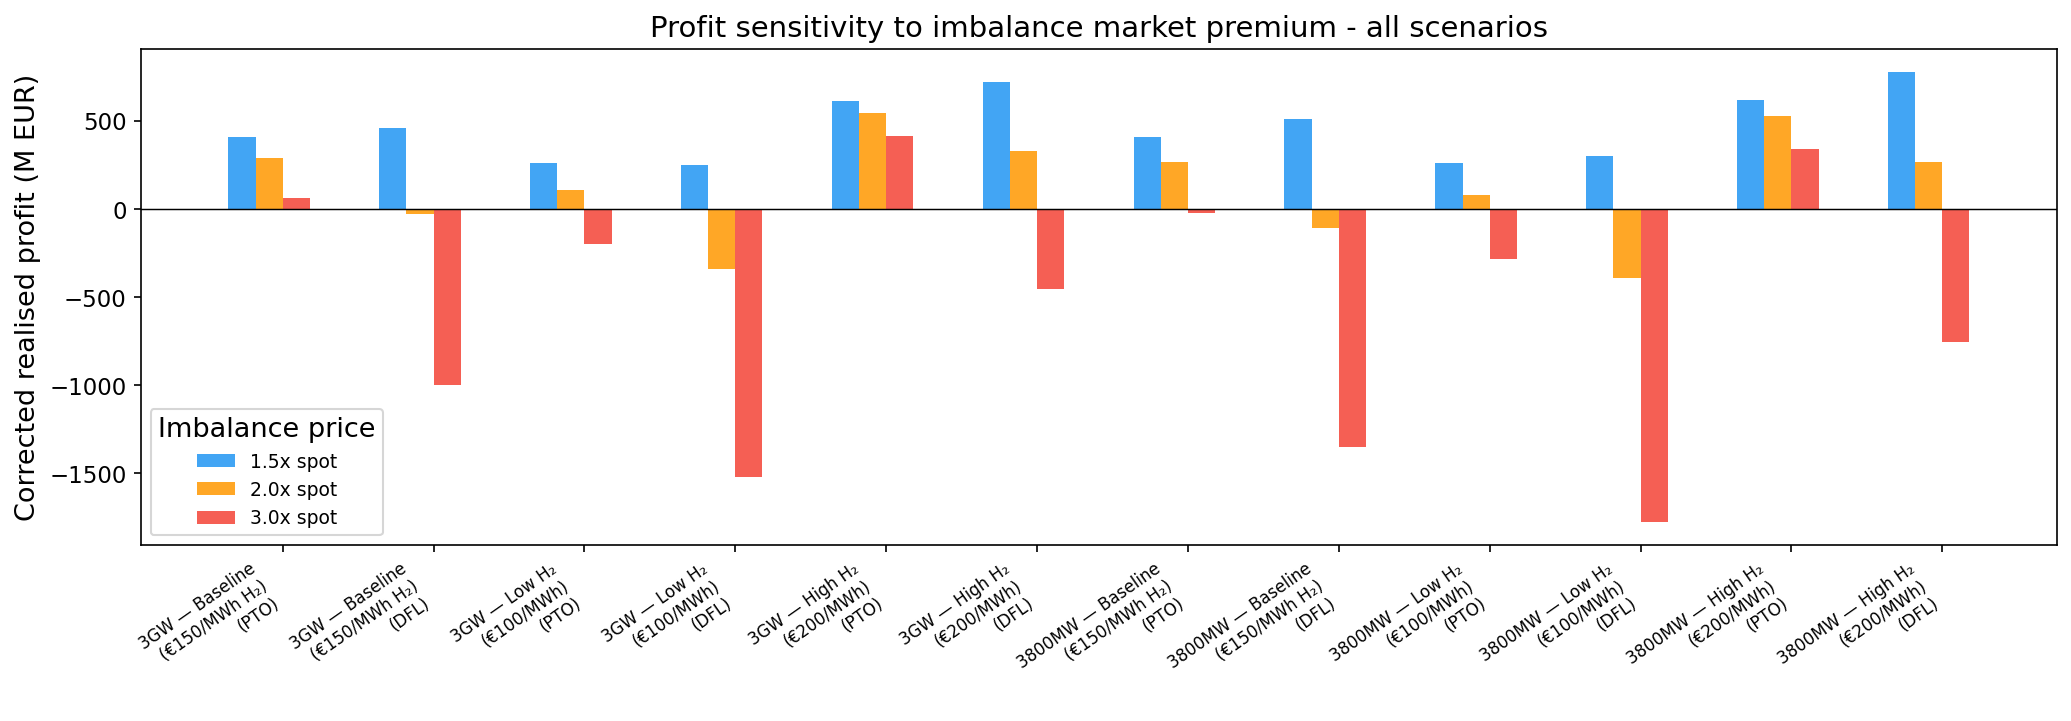

In [34]:
#  Imbalance price sensitivity table 


from scenarios import find_scenario as _find_scen
DELTA_T = 0.25
PREMIUMS = [1.5, 2.0, 3.0]


imb_rows = []
for wf, scen, label in ALL_SCENARIOS:
    for tag, dsp_file in [('PTO', 'dispatch_pto.parquet'), ('DFL', 'dispatch_dfl.parquet')]:
        if tag == 'PTO':
            d_dir = ML_RESULTS_DIR / f'pto_{wf}_test_{MODEL_NAME}_{scen}'
        else:
            d_dir = ML_RESULTS_DIR / f'dfl_{wf}_{MODEL_NAME}_{scen}'
        dsp_path = d_dir / dsp_file
        sum_path = d_dir / 'summary.json'
        if not dsp_path.exists() or not sum_path.exists():
            continue
        dsp = pd.read_parquet(dsp_path)
        with open(sum_path) as fh:
            summ = json.load(fh)


        actual   = dsp['P_wind_actual'].values
        pg       = dsp['P_grid'].values
        p_dis    = dsp['P_dis'].values
        p_ely    = dsp['P_ely'].values
        p_ch     = dsp['P_ch'].values
        surplus  = actual + p_dis - pg - p_ely - p_ch
        after_grid = np.maximum(-surplus, 0.0)
        ely_shed   = np.minimum(p_ely, after_grid)
        after_ely  = after_grid - ely_shed
        ch_shed    = np.minimum(p_ch, after_ely)
        deficit_mw = np.maximum(after_ely - ch_shed, 0.0)

        spot = dsp['spot_price'].values if 'spot_price' in dsp.columns else np.zeros(len(dsp))
        base_profit = summ.get('realized_profit', 0.0)

        row = {'Scenario': label, 'Model': tag, 'Reported (M EUR)': round(base_profit / 1e6, 1)}
        for prem in PREMIUMS:
            imb_cost = DELTA_T * (deficit_mw * spot * (prem - 1)).sum()
            row[f'{prem:.1f}x spot'] = round((base_profit - imb_cost) / 1e6, 1)
        imb_rows.append(row)

if imb_rows:
    df_imb = pd.DataFrame(imb_rows)
    print('Realised profit (M EUR) corrected for imbalance cost at different spot premiums')
    print('=' * 90)
    print(df_imb.to_string(index=False))


    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(imb_rows))
    width = 0.18
    colours = ['#2196F3', '#FF9800', '#F44336', '#9C27B0']
    for j, prem in enumerate(PREMIUMS):
        col = f'{prem:.1f}x spot'
        vals = [r[col] for r in imb_rows]
        ax.bar(x + j * width, vals, width, label=f'{prem:.1f}x spot', color=colours[j], alpha=0.85)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels([f"{r['Scenario']}\n({r['Model']})" for r in imb_rows],
                       rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Corrected realised profit (M EUR)')
    ax.set_title('Profit sensitivity to imbalance market premium - all scenarios')
    ax.legend(title='Imbalance price', fontsize=9)
    ax.axhline(0, color='black', lw=0.7)
    fig.tight_layout()
    plt.show()
else:
    print('No dispatch data found - check ML_RESULTS_DIR paths.')
